# South Africa JUSTICE project notebook — integrated project workflow


## 0. Setup and file locations

In [1]:
# =============================================================================
# 1. STANDARD LIBRARY IMPORTS
# =============================================================================
import copy
import glob
import json
import os
import re
import shlex
import sys
import time
import warnings
from pathlib import Path
import importlib
import geopandas as gpd

# Waarschuwingen direct globaal negeren voor een schone output
warnings.filterwarnings("ignore")

# =============================================================================
# 2. DATA SCIENCE & PLOTTING IMPORTS
# =============================================================================
import geopandas as gpd
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.path as _mpath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize

# Indien nodig voor headless environments (was aanwezig in cell 62):
# matplotlib.use("Agg")

# =============================================================================
# 3. EMA WORKBENCH & PLATYPUS IMPORTS
# =============================================================================
from ema_workbench import (
    CategoricalParameter,
    Constant,
    Model,
    MultiprocessingEvaluator,
    RealParameter,
    Sample,
    ScalarOutcome,
    ema_logging,
)
from ema_workbench.em_framework.optimization import GenerationalBorg
from platypus import Real


In [2]:
# Try to detect notebook directory. In VS Code notebooks, __vsc_ipynb_file__ is available.
#iets erin voor push
try:
    _NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path.cwd().resolve()

# Find repo root: the folder that contains JUSTICE-main and config
_REPO_ROOT = _NOTEBOOK_DIR
for candidate in [_NOTEBOOK_DIR] + list(_NOTEBOOK_DIR.parents):
    if (candidate / "JUSTICE-main").exists() and (candidate / "config").exists():
        _REPO_ROOT = candidate
        break

_JUSTICE_ROOT = (_REPO_ROOT / "JUSTICE-main").resolve()
_CONFIG_DIR = (_REPO_ROOT / "config").resolve()

# Project/group folder
_PROJECT_DIR = (_REPO_ROOT / "A- Project G15").resolve()

# Important: keep all generated project files inside A- Project G15
RESULTS_DIR = (_PROJECT_DIR / "results_rival").resolve()
PLOTS_DIR = (_PROJECT_DIR / "plots_rival").resolve()

# Config folder should already exist; results and plots can be created
for path in [RESULTS_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(_JUSTICE_ROOT) not in sys.path:
    sys.path.insert(0, str(_JUSTICE_ROOT))

# Some JUSTICE imports assume the working directory is JUSTICE-main.
# This does NOT affect RESULTS_DIR/PLOTS_DIR because they are absolute Path objects.
os.chdir(_JUSTICE_ROOT)

from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction, Scenario

print("Notebook dir:", _NOTEBOOK_DIR)
print("Repo root:", _REPO_ROOT)
print("Project dir:", _PROJECT_DIR)
print("JUSTICE root:", _JUSTICE_ROOT)
print("Config dir:", _CONFIG_DIR)
print("Results dir:", RESULTS_DIR)
print("Plots dir:", PLOTS_DIR)

assert RESULTS_DIR == (_PROJECT_DIR / "results_rival").resolve()

Notebook dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
Repo root: /Users/wesselmuntendam/Model Based Decision Making/epa141a
Project dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
JUSTICE root: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Config dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/config
Results dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival
Plots dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots_rival


In [3]:
# Zet JUSTICE-main absoluut vooraan
sys.path = [str(_JUSTICE_ROOT)] + [
    p for p in sys.path
    if Path(p).resolve() != _JUSTICE_ROOT.resolve()
]

# Verwijder oude config/justice imports
for module in list(sys.modules):
    if module == "config" or module.startswith("config."):
        del sys.modules[module]
    if module == "justice" or module.startswith("justice."):
        del sys.modules[module]

print("PROJECT_ROOT exists:", _JUSTICE_ROOT.exists())
print("justice exists:", (_JUSTICE_ROOT / "justice").exists())
print("default_parameters exists:", (_JUSTICE_ROOT / "config" / "default_parameters.py").exists())

#print("config:", importlib.util.find_spec("config"))
#print("config.default_parameters:", importlib.util.find_spec("config.default_parameters"))

# =============================================================================
# 4. JUSTICE MODEL IMPORTS
# =============================================================================
from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.enumerations import (
    Abatement,
    DamageFunction,
    Economy,
    Scenario,
    WelfareFunction,
)
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

PROJECT_ROOT exists: True
justice exists: True
default_parameters exists: True


In [4]:
# Basic model dimensions used in Assignment 4 and later optimisation.
# These are the standard values used in the assignment setup.
N_REGIONS = 57
N_INPUTS = 2
N_RBFS = N_INPUTS + 2
START_YEAR = 2015
END_YEAR = 2300
TIMESTEP = 1
DATA_TIMESTEP = 5
SMALL_NUMBER = 1e-9
# We get the exact region list from JUSTICE. This is light compared with full optimisation.
JUSTICE.hard_reset()
_model_probe = JUSTICE(
    start_year=START_YEAR,
    end_year=END_YEAR,
    timestep=TIMESTEP,
    scenario=2,
    climate_ensembles=1,
    stochastic_run=False,
    social_welfare_function=WelfareFunction.UTILITARIAN,
)

REGION_LIST = list(_model_probe.data_loader.REGION_LIST)
N_REGIONS = len(REGION_LIST)
N_TIMESTEPS = len(_model_probe.time_horizon.model_time_horizon)
zaf_idx = REGION_LIST.index("zaf")

print("Number of regions:", N_REGIONS)
print("Number of timesteps:", N_TIMESTEPS)
print("South Africa index:", zaf_idx)
print("First 10 regions:", REGION_LIST[:10])

Number of regions: 57
Number of timesteps: 286
South Africa index: 56
First 10 regions: ['arg', 'aus', 'aut', 'bel', 'bgr', 'blt', 'bra', 'can', 'chl', 'chn']


## 1. Frame South Africa's Rival Framing


### 1.1 Mandate translated to model terms

In [5]:
ACTOR = "South Africa"
KEY_REGION = "zaf"
PREFERRED_WELFARE = WelfareFunction.UTILITARIAN
RIVAL_WELFARE = WelfareFunction.PRIORITARIAN

south_africa_actor_frame = {
    "actor": ACTOR,
    "key_region": KEY_REGION,
    "preferred_welfare_function": PREFERRED_WELFARE.name,
    "rival_welfare_function": RIVAL_WELFARE.name,
    "core_metric": "abatement_cost / gross_economic_output",
    "main_claim": (
        "South Africa supports mitigation, but equal obligations are not equally fair "
        "when transition costs are unequal relative to economic capacity."
    ),
}

south_africa_actor_frame

{'actor': 'South Africa',
 'key_region': 'zaf',
 'preferred_welfare_function': 'UTILITARIAN',
 'rival_welfare_function': 'PRIORITARIAN',
 'core_metric': 'abatement_cost / gross_economic_output',
 'main_claim': 'South Africa supports mitigation, but equal obligations are not equally fair when transition costs are unequal relative to economic capacity.'}

### 1.3 Optional initial model intuition: BAU and welfare-function comparison

In [6]:
RUN_OPTIONAL_BAU_WELFARE_COMPARISON = True

if RUN_OPTIONAL_BAU_WELFARE_COMPARISON:
    welfare_functions = {
        "Utilitarian": WelfareFunction.UTILITARIAN,
        "Prioritarian": WelfareFunction.PRIORITARIAN,
        "Sufficientarian": WelfareFunction.SUFFICIENTARIAN,
    }

    results_wf = {}

    for wf_name, wf in welfare_functions.items():
        print(f"Running BAU welfare comparison for: {wf_name}")

        JUSTICE.hard_reset()
        model = JUSTICE(
            start_year=START_YEAR,
            end_year=END_YEAR,
            timestep=TIMESTEP,
            scenario=2,
            climate_ensembles=1,
            stochastic_run=False,
            social_welfare_function=wf,
        )

        ecr_bau = np.zeros(
            (
                len(model.data_loader.REGION_LIST),
                len(model.time_horizon.model_time_horizon),
            )
        )

        model.run(emission_control_rate=ecr_bau, endogenous_savings_rate=True)
        data = model.evaluate()

        welfare_value = np.asarray(data["welfare"]).item()
        results_wf[wf_name] = float(welfare_value)

    results_wf_df = pd.DataFrame.from_dict(
        results_wf,
        orient="index",
        columns=["BAU welfare"]
    )

    display(results_wf_df)

else:
    print("Skipping optional BAU welfare comparison.")

Running BAU welfare comparison for: Utilitarian
Running BAU welfare comparison for: Prioritarian
Running BAU welfare comparison for: Sufficientarian


,BAU welfare
Utilitarian,-103.721111
Prioritarian,-414.827668
Sufficientarian,-104.187375


## 2. Build the optimisation setup

### 2.1 Adaptive RBF policy design

In [7]:
# Assignment 4 — RBF decision variable structure.

n_rbfs = N_RBFS # dit is dus al ingevuld 
n_inputs = N_INPUTS
n_outputs = N_REGIONS
 

n_centers = n_rbfs * n_inputs
n_radii = n_rbfs * n_inputs
n_weights = n_rbfs * n_outputs
n_total = n_centers + n_radii + n_weights

rbf_structure = pd.DataFrame([
    {"Component": "Centers", "Formula": "n_rbfs * n_inputs", "Count": n_centers},
    {"Component": "Radii", "Formula": "n_rbfs * n_inputs", "Count": n_radii},
    {"Component": "Weights", "Formula": "n_rbfs * n_outputs", "Count": n_weights},
    {"Component": "Total", "Formula": "centers + radii + weights", "Count": n_total},
])

rbf_structure

,Component,Formula,Count
0,Centers,n_rbfs * n_inputs,8
1,Radii,n_rbfs * n_inputs,8
2,Weights,n_rbfs * n_outputs,228
3,Total,centers + radii + weights,244


**Interpretation for report:**

> The RBF structure uses 244 decision variables. These variables encode an adaptive decision rule rather than a fixed mitigation action for every region and every year. This is politically relevant for South Africa because it avoids assuming that all countries must follow the same rigid mitigation pathway regardless of climate response or transition burden.

### 2.2 Welfare function choice

In [8]:
WELFARE_OPTIONS = {
    "Utilitarian": WelfareFunction.UTILITARIAN,
    "Prioritarian": WelfareFunction.PRIORITARIAN,
    "Egalitarian": WelfareFunction.EGALITARIAN,
}

print("Welfare functions considered:")
for name, wf in WELFARE_OPTIONS.items():
    print(f"  {name:<20s} internal index = {wf.value[0]}")

CHOSEN_WELFARE_FUNCTION = WELFARE_OPTIONS["Utilitarian"]
CHOSEN_WELFARE_FUNCTION_IDX = CHOSEN_WELFARE_FUNCTION.value[0]

print(f"\nChosen: {CHOSEN_WELFARE_FUNCTION.name} (index {CHOSEN_WELFARE_FUNCTION_IDX})")
#print("Rationale: Prioritarian welfare fits South Africa because it gives extra weight to worse-off regions.")

Welfare functions considered:
  Utilitarian          internal index = 0
  Prioritarian         internal index = 1
  Egalitarian          internal index = 3

Chosen: UTILITARIAN (index 0)


### 2.3 Reference SSP-RCP scenario

### 2.1 Adaptive RBF policy design

In [9]:
CHOSEN_SCENARIO_INDEX = 2
CHOSEN_SCENARIO_NAME = "SSP2-RCP4.5"

print(f"Chosen reference scenario: {CHOSEN_SCENARIO_INDEX} — {CHOSEN_SCENARIO_NAME}")

Chosen reference scenario: 2 — SSP2-RCP4.5


### 2.4 FaIR ensemble strategy

In [10]:
FULL_ENSEMBLE_SIZE = 1001
N_ENSEMBLE_LOCAL = 15

rng = np.random.default_rng(seed=42)
ensemble_indices = sorted(
    rng.choice(FULL_ENSEMBLE_SIZE, size=N_ENSEMBLE_LOCAL, replace=False).tolist()
)

speedup = FULL_ENSEMBLE_SIZE / N_ENSEMBLE_LOCAL

print("Selected ensemble indices:", ensemble_indices)
print(f"Approximate speedup vs full ensemble: {speedup:.1f}x")

Selected ensemble indices: [85, 88, 93, 200, 429, 434, 524, 647, 693, 718, 735, 761, 764, 851, 973]
Approximate speedup vs full ensemble: 66.7x


### 2.5 Objectives and epsilon values

In [11]:
EPSILONS = [
    1.0,   # welfare
    0.01,   # fraction_above_threshold
    10.0,   # welfare_loss_damage
    10.0,   # welfare_loss_abatement
    0.001,
]

objectives =[
    ScalarOutcome("welfare", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("fraction_above_threshold", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage", kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("welfare_loss_abatement", kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("abatement_burden", kind=ScalarOutcome.MINIMIZE),
]

objective_table = pd.DataFrame([
    {
        "Objective": obj.name,
        "Direction": "MINIMIZE" if obj.kind == ScalarOutcome.MINIMIZE else "MAXIMIZE",
        "Epsilon": eps,
        "South Africa interpretation": interp,
    }
    for obj, eps, interp in zip(
        objectives,
        EPSILONS,
        [
            "Lower welfare loss is better.",
            "Lower probability/fraction above 2°C is better.",
            "Assignment convention: larger stored value means less actual damage burden.",
            "Assignment convention: larger stored value means less actual abatement burden.",
            "Lower South Africa abatement cost as share of gross output is better.",
        ],
    )
])

objective_table

,Objective,Direction,Epsilon,South Africa interpretation
0,welfare,MINIMIZE,1.000,Lower welfare loss is better.
1,fraction_above_threshold,MINIMIZE,0.010,Lower probability/fraction above 2°C is better.
2,welfare_loss_damage,MAXIMIZE,10.000,Assignment convention: larger stored value mea...
3,welfare_loss_abatement,MAXIMIZE,10.000,Assignment convention: larger stored value mea...
4,abatement_burden,MINIMIZE,0.001,Lower South Africa abatement cost as share of ...


### 2.6 Save Assignment 4 configuration

**Source:** Assignment 4, Task 5.5.  
**Project role:** create the config used by Assignment 5.

This config is the bridge from problem framing to optimisation.

In [12]:
student_config = {
    "start_year": START_YEAR,
    "end_year": END_YEAR,
    "data_timestep": DATA_TIMESTEP,
    "timestep": TIMESTEP,
    "emission_control_start_year": 2025,
    "n_rbfs": N_RBFS,
    "n_inputs": N_INPUTS,
    "epsilons": EPSILONS,
    "temperature_year_of_interest": 2100,
    "reference_ssp_rcp_scenario_index": CHOSEN_SCENARIO_INDEX,

    # These extra keys are useful for newer/local scripts. If a script ignores them, that is fine.
    "stochastic_run": False,
    "climate_ensemble_members": ensemble_indices,
    "social_welfare_function_type": CHOSEN_WELFARE_FUNCTION_IDX,
}

assert student_config["n_rbfs"] == student_config["n_inputs"] + 2
assert len(student_config["epsilons"]) == len(objectives)
assert all(e > 0 for e in student_config["epsilons"])
assert student_config["emission_control_start_year"] >= student_config["start_year"]

config_path = _CONFIG_DIR / "config_student_uti.json"
with open(config_path, "w") as fh:
    json.dump(student_config, fh, indent=4)

print(f"Config saved → {config_path}")
print(json.dumps(student_config, indent=4))

Config saved → /Users/wesselmuntendam/Model Based Decision Making/epa141a/config/config_student_uti.json
{
    "start_year": 2015,
    "end_year": 2300,
    "data_timestep": 5,
    "timestep": 1,
    "emission_control_start_year": 2025,
    "n_rbfs": 4,
    "n_inputs": 2,
    "epsilons": [
        1.0,
        0.01,
        10.0,
        10.0,
        0.001
    ],
    "temperature_year_of_interest": 2100,
    "reference_ssp_rcp_scenario_index": 2,
    "stochastic_run": false,
    "climate_ensemble_members": [
        85,
        88,
        93,
        200,
        429,
        434,
        524,
        647,
        693,
        718,
        735,
        761,
        764,
        851,
        973
    ],
    "social_welfare_function_type": 0
}


## 3. Generate candidate policies through MOEA

### 3.1 Local optimisation run

Start with a small test run to ensure everything works. Increase `NFE` later if time allows.

- `NFE` = number of candidate policies tested per seed.
- `SEEDS` = independent optimiser runs.
- `N_ENSEMBLES` = climate ensemble members used during local optimisation.

In [13]:
with open(config_path) as fh:
    cfg = json.load(fh)

explanations = {
    "start_year":                       "Simulation start year",
    "end_year":                         "Simulation end year",
    "data_timestep":                    "Years between raw input data points",
    "timestep":                         "Model integration timestep (years)",
    "emission_control_start_year":      "First year ECR can exceed zero",
    "n_rbfs":                           "Number of RBFs (effective: n_inputs + 2)",
    "n_inputs":                         "RBF input signals ",
    "epsilons":                         "Archive granularity",
    "temperature_year_of_interest":     "Year for threshold fraction evaluation",
    "reference_ssp_rcp_scenario_index": "Reference scenario index",
}

print(f"Configuration: {config_path}\n")
for k, v in cfg.items():
    print(f"  {k:<40s}  {str(v):<15}  # {explanations.get(k, '')}")

Configuration: /Users/wesselmuntendam/Model Based Decision Making/epa141a/config/config_student_uti.json

  start_year                                2015             # Simulation start year
  end_year                                  2300             # Simulation end year
  data_timestep                             5                # Years between raw input data points
  timestep                                  1                # Model integration timestep (years)
  emission_control_start_year               2025             # First year ECR can exceed zero
  n_rbfs                                    4                # Number of RBFs (effective: n_inputs + 2)
  n_inputs                                  2                # RBF input signals 
  epsilons                                  [1.0, 0.01, 10.0, 10.0, 0.001]  # Archive granularity
  temperature_year_of_interest              2100             # Year for threshold fraction evaluation
  reference_ssp_rcp_scenario_index          2    

In [14]:
# VOOR MAC NIET RUNNEN
NFE = 100000
SEEDS = [1, 2, 3, 4, 5]
N_ENSEMBLES = N_ENSEMBLE_LOCAL
N_PROCESSES = None
OUTPUT_DIR = RESULTS_DIR

seeds_str = " ".join(str(s) for s in SEEDS)
n_proc_arg = f"--n_processes {N_PROCESSES}" if N_PROCESSES else ""

script_path = (_PROJECT_DIR / "run_optimization_local_uti.py").resolve()

cmd = (
    f"python {shlex.quote(str(script_path))} "
    f"--nfe {NFE} "
    f"--seeds {seeds_str} "
    f"--n_ensembles {N_ENSEMBLES} "
    f"--output_dir {shlex.quote(str(OUTPUT_DIR))} "
    f"--config {shlex.quote(str(config_path))} "
    + n_proc_arg
)

print("Command to run:")
print(cmd)

ret = os.system(cmd)
print(f"\nExit code: {ret} ({'OK' if ret == 0 else 'ERROR'})")

Command to run:
python '/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/run_optimization_local_uti.py' --nfe 100000 --seeds 1 2 3 4 5 --n_ensembles 15 --output_dir '/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival' --config '/Users/wesselmuntendam/Model Based Decision Making/epa141a/config/config_student_uti.json' 
JUSTICE — Local MOEA Optimisation  (Assignment 5)
  Welfare function  : UTILITARIAN
  Config            : /Users/wesselmuntendam/Model Based Decision Making/epa141a/config/config_student_uti.json
  NFE per seed      : 100,000
  Seeds (5)        : [1, 2, 3, 4, 5]
  FAIR ensembles    : 15  (indices ≈ [np.int64(1), np.int64(72), np.int64(143), np.int64(215), np.int64(286), np.int64(357), np.int64(429), np.int64(500), np.int64(571), np.int64(643), np.int64(714), np.int64(785), np.int64(857), np.int64(928), np.int64(1000)])
  Population size   : 100
  Worker processes  : auto
  Output directory  : /Users/wesselmunte

Process SpawnPoolWorker-1:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/miniconda3/envs/epa141/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/epa141/lib/python3.12/multiprocessing/spawn.py", line 131, in _main
    prepare(preparation_data)
  File "/opt/miniconda3/envs/epa141/lib/python3.12/multiprocessing/spawn.py", line 246, in prepare
    _fixup_main_from_path(data['init_main_from_path'])
  File "/opt/miniconda3/envs/epa141/lib/python3.12/multiprocessing/spawn.py", line 297, in _fixup_main_from_path
    main_content = runpy.run_path(main_path,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen runpy>", line 287, in run_path
  File "<frozen runpy>", line 98, in _run_module_code
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15


Exit code: 2 (ERROR)


In [ ]:

# VOOR WINDOWS NIET RUNNEN

NFE = 100
SEEDS = [1, 2, 3, 4, 5]
N_ENSEMBLES = N_ENSEMBLE_LOCAL
N_PROCESSES = None
OUTPUT_DIR = RESULTS_DIR

seeds_str = " ".join(str(s) for s in SEEDS)
n_proc_arg = f"--n_processes {N_PROCESSES}" if N_PROCESSES else ""

script_path = (_PROJECT_DIR / "run_optimization_local_uti.py").resolve()

# We gebruiken hier f-strings met ' ' aan de buitenkant,
# zodat we echte " " om de Windows-paden heen kunnen zetten.
cmd = (
    f'python "{script_path}" '
    f"--nfe {NFE} "
    f"--seeds {seeds_str} "
    f"--n_ensembles {N_ENSEMBLES} "
    f'--output_dir "{OUTPUT_DIR}" '
    f'--config "{config_path}" '
    + n_proc_arg
)

print("Command to run:")
print(cmd)

ret = os.system(cmd)
print(f"\nExit code: {ret} ({'OK' if ret == 0 else 'ERROR'})")

---
Each completed seed produces a directory e.g.  `<welfare_function>_<nfe>_<seed>/` inside `results/` containing:
- `pareto_front_<seed>.csv` — the final Pareto-optimal solutions (levers + objectives).
- `<welfare_function>_<nfe>_<seed>.tar.gz` — the ArchiveLogger convergence history (used in Assignment 6).
- `convergence_<seed>.csv` — EpsilonProgress and operator probabilities per NFE checkpoint (used in Assignment 6).

Load all available Pareto front CSVs and print a statistical summary.
>Tip: you can use print(all_results[OBJECTIVE_COLS].describe().round(n))
Print the nfes, and number of solutions in the pareto front as well.

In [15]:

OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden"
]

# Find all Pareto front CSV files in the results directory
pareto_files = sorted(Path(RESULTS_DIR).rglob("pareto_front_*.csv"))

print(f"Results directory: {RESULTS_DIR}")
print(f"Found {len(pareto_files)} Pareto front file(s).")

if len(pareto_files) == 0:
    raise FileNotFoundError(
        f"No pareto_front_*.csv files found in {RESULTS_DIR}. "
        "Check whether the optimisation wrote results to the correct folder."
    )

all_dfs = []

for file in pareto_files:
    df = pd.read_csv(file)

    # Folder name should look like PRIORITARIAN_500_9845531
    folder_name = file.parent.name
    parts = folder_name.split("_")

    welfare_function = parts[0] if len(parts) >= 1 else "unknown"
    nfe = int(parts[1]) if len(parts) >= 2 and parts[1].isdigit() else np.nan

    # File name should look like pareto_front_9845531.csv
    seed_match = re.search(r"pareto_front_(\d+)\.csv", file.name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    df["welfare_function"] = welfare_function
    df["nfe"] = nfe
    df["seed"] = seed
    df["source_file"] = str(file)

    all_dfs.append(df)

all_results = pd.concat(all_dfs, ignore_index=True)

# Optional: keep only the current South Africa welfare-function runs
# Uncomment if old UTILITARIAN runs are still in the results folder.
# all_results = all_results[all_results["welfare_function"] == "PRIORITARIAN"].copy()

# Check that all objective columns are available
missing_cols = [col for col in OBJECTIVE_COLS if col not in all_results.columns]
if missing_cols:
    raise KeyError(f"Missing objective columns in loaded Pareto fronts: {missing_cols}")

# Print nfes and number of solutions in each Pareto front
run_summary = (
    all_results
    .groupby(["welfare_function", "nfe", "seed"], dropna=False)
    .size()
    .reset_index(name="n_pareto_solutions")
    .sort_values(["welfare_function", "nfe", "seed"])
)

print("\nNFE and number of Pareto solutions per completed seed:")
display(run_summary)

print("\nStatistical summary of objective columns across all loaded Pareto solutions:")
display(all_results[OBJECTIVE_COLS].describe().round(3))

Results directory: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival
Found 5 Pareto front file(s).

NFE and number of Pareto solutions per completed seed:


,welfare_function,nfe,seed,n_pareto_solutions
0,UTILITARIAN,100000,1,19
1,UTILITARIAN,100000,2,21
2,UTILITARIAN,100000,3,18
3,UTILITARIAN,100000,4,24
4,UTILITARIAN,100000,5,20



Statistical summary of objective columns across all loaded Pareto solutions:


,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement,abatement_burden
count,102.000,102.000,102.000,102.000,102.000
mean,103.657,0.766,3636.461,11761.336,0.007
std,0.069,0.139,7.597,3325.120,0.004
min,103.536,0.533,3618.171,10780.333,0.000
25%,103.606,0.667,3632.783,10812.129,0.003
50%,103.667,0.733,3640.060,10828.657,0.007
75%,103.692,0.867,3641.072,10909.002,0.009
max,103.840,1.000,3645.964,26006.790,0.015


In [16]:
# Verify results are non-trivial:
# A non-trivial Pareto front should have:
#   - More than 1 solution
#   - Some variation in all four objective columns
#   - fraction_above_threshold < 1.0 for at least some solutions
#     (meaning the MOEA found policies better than BAU)

# Step 3 — Verify results are non-trivial

variation = all_results[OBJECTIVE_COLS].nunique(dropna=True)

has_more_than_one_solution = len(all_results) > 1
has_variation_all_objectives = (variation > 1).all()
has_some_fraction_below_1 = (all_results["fraction_above_threshold"] < 1.0).any()

non_trivial_checks = pd.DataFrame({
    "Check": [
        "More than 1 solution",
        "Variation in all four objective columns",
        "At least one solution has fraction_above_threshold < 1.0",
    ],
    "Result": [
        has_more_than_one_solution,
        has_variation_all_objectives,
        has_some_fraction_below_1,
    ],
})

display(non_trivial_checks)

print("\nVariation per objective column:")
display(variation.to_frame("n_unique_values"))

if not has_more_than_one_solution:
    print("Warning: Only one solution loaded. This is not enough for a meaningful Pareto front.")

if not has_variation_all_objectives:
    print("Warning: At least one objective has no variation. This may be due to very low NFE or a setup issue.")

if not has_some_fraction_below_1:
    print("Warning: All solutions have fraction_above_threshold = 1.0. The run may not have found climate-effective policies yet.")

#YOUR CODE HERE

,Check,Result
0,More than 1 solution,True
1,Variation in all four objective columns,True
2,At least one solution has fraction_above_thres...,True



Variation per objective column:


,n_unique_values
welfare,98
fraction_above_threshold,8
welfare_loss_damage,98
welfare_loss_abatement,98
abatement_burden,98


## 4. Check search quality and build a reference set

**Project purpose:** avoid basing advice on one random optimiser run.

**Main source:** Assignment 6 — convergence and reference set.  
**Input:** Assignment 5 archives from multiple seeds.  
**Output:** combined reference set and convergence evidence.

This is the step that was easy to lose, but it is important:

> Assignment 6 checks whether the search sufficiently explored the policy space.

For the report, this is mostly a **credibility step**, not the main political argument.

In [17]:

# ── Discover Pareto-front CSVs — grouped by NFE ───────────────────────────────
csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "pareto_front_*.csv"), recursive=True
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv found in {RESULTS_DIR}.\n"
        "Run Assignment 5 (run_optimization_local_uti.py) first."
    )

# nfe_groups[nfe][seed] = DataFrame
nfe_groups = {}

for path in csv_paths:
    dir_name = os.path.basename(os.path.dirname(path))
    parts    = dir_name.split("_")

    try:
        nfe  = int(parts[-2])
        seed = int(parts[-1])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0

    df = pd.read_csv(path)

    # Keep only valid/non-penalty policies
    df = df[df["welfare"] < 1e5].reset_index(drop=True)

    # Prevent zero radii/weights from old saved Pareto-front policies
    radii_cols = [c for c in df.columns if c.startswith("radii")]
    weights_cols = [c for c in df.columns if c.startswith("weights")]

    if radii_cols:
        df[radii_cols] = df[radii_cols].clip(lower=SMALL_NUMBER)

    if weights_cols:
        df[weights_cols] = df[weights_cols].clip(lower=SMALL_NUMBER)

    nfe_groups.setdefault(nfe, {})[seed] = df
# ── Discover convergence archives — keyed by (nfe, seed) ─────────────────────
archive_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "UTILITARIAN_*.tar.gz"), recursive=True
))

nfe_seed_archives = {}   # (nfe, seed) → path
for p in archive_paths:
    parts    = os.path.basename(p).replace(".tar.gz", "").split("_")
    seed_val = int(parts[-1])
    nfe_val  = int(parts[-2])
    nfe_seed_archives[(nfe_val, seed_val)] = p

# ── Discover convergence CSVs — keyed by (nfe, seed) ─────────────────────────
# Saved by run_optimization_local_uti.py as results/<welfare_function>_<nfe>_<seed>/convergence_<seed>.csv
conv_csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_DIR, "**", "convergence_*.csv"), recursive=True
))

nfe_seed_convergence = {}   # (nfe, seed) → DataFrame
for p in conv_csv_paths:
    dir_name = os.path.basename(os.path.dirname(p))
    parts    = dir_name.split("_")
    try:
        nfe_val  = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        seed_val = int(os.path.basename(p).replace("convergence_", "").replace(".csv", ""))
        nfe_val  = 0
    df_conv = pd.read_csv(p, index_col=0)
    nfe_seed_convergence[(nfe_val, seed_val)] = df_conv

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"NFE groups found: {sorted(nfe_groups)}")
print()
rows = []
for nfe in sorted(nfe_groups):
    for seed, df in sorted(nfe_groups[nfe].items()):
        rows.append({
            "nfe_budget":      nfe,
            "seed":            seed,
            "n_solutions":     len(df),
            "has_archive":     (nfe, seed) in nfe_seed_archives,
            "has_conv_csv":    (nfe, seed) in nfe_seed_convergence,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\n{len(nfe_seed_archives)} archive(s) | {len(nfe_seed_convergence)} convergence CSV(s)")

NFE groups found: [100000]

 nfe_budget  seed  n_solutions  has_archive  has_conv_csv
     100000     1           19        False          True
     100000     2           21         True          True
     100000     3           18         True          True
     100000     4           24         True          True
     100000     5           20         True          True

4 archive(s) | 5 convergence CSV(s)


In [18]:
def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# EMA Workbench -- core optimization
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    PlatypusProblem,
    load_archives,
)
# EMA Workbench -- native convergence metrics (3.0+)
from ema_workbench.em_framework.optimization_convergence import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
)
from platypus import Real

# Objective metadata
# Objective metadata
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement", "abatement_burden"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold", "abatement_burden"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
    "abatement_burden":         "SA Abatement Burden\n(MINIMIZE)"
}

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_DIR}")
print("EMA Workbench native convergence metrics : OK")

JUSTICE root : /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Results root : /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival
EMA Workbench native convergence metrics : OK


### Building the reference set

In [19]:
# Build the Platypus problem descriptor and reference sets

_sample_df = next(df for nfe in nfe_groups for df in nfe_groups[nfe].values())

# Only RBF decision variables are levers
_lever_cols = [
    c for c in _sample_df.columns
    if c.startswith("center ") or c.startswith("radii ") or c.startswith("weights ")
]

_lever_cols_s = [c.replace(" ", "_") for c in _lever_cols]
_n_vars = len(_lever_cols)

print(f"Detected {_n_vars} lever columns.")
problem = PlatypusProblem(_n_vars, len(OBJECTIVE_COLS))

problem.types = (
    [Real(-1.0, 1.0)] * 8
    + [Real(0.0, 1.0)] * 8
    + [Real(0.0, 1.0)] * 228
)

problem.directions = [
    PlatypusProblem.MINIMIZE,
    PlatypusProblem.MINIMIZE,
    PlatypusProblem.MAXIMIZE,
    PlatypusProblem.MAXIMIZE,
    PlatypusProblem.MINIMIZE,
]

problem.parameter_names = _lever_cols_s
problem.outcome_names = OBJECTIVE_COLS

# Compatibility patch for this EMA Workbench version:
# Sample._from_platypus_solution expects decision_variables with .name and .shape.
class _DummyDecisionVariable:
    def __init__(self, name):
        self.name = name
        self.shape = None

problem.decision_variables = [
    _DummyDecisionVariable(name) for name in _lever_cols_s
]

# Use the same epsilons as in your optimisation config
EPSILONS = [10.0, 0.01, 10.0, 10.0, 0.001]

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))

def restore_cols(df):
    return df.rename(
        columns=lambda c: c.replace("_", " ", 1)
        if c.startswith(("center_", "radii_", "weights_"))
        else c
    )

# Build one reference set per NFE group
nfe_ref_sets = {}

for nfe in sorted(nfe_groups):
    seed_dict = nfe_groups[nfe]

    dfs_san = []
    for seed, df in seed_dict.items():
        keep_cols = _lever_cols + OBJECTIVE_COLS
        df_clean = df[keep_cols].dropna(subset=OBJECTIVE_COLS).copy()

        # Remove penalty / failed solutions
        df_clean = df_clean[df_clean["welfare"] < 1e5].copy()

        dfs_san.append(sanitize_cols(df_clean))

    n_in = sum(len(d) for d in dfs_san)
    print(f"\nNFE={nfe:,}: merging {n_in} solutions from {len(seed_dict)} seed(s)...")

    ref_s = epsilon_nondominated(dfs_san, EPSILONS, problem)
    ref = restore_cols(ref_s)

    nfe_ref_sets[nfe] = ref

    pruning = (1 - len(ref) / n_in) * 100 if n_in > 0 else 0
    print(f"  Reference set: {len(ref)} solutions (pruned {pruning:.0f}%)")

    print("  Objective ranges:")
    for col in OBJECTIVE_COLS:
        print(f"    {col:<40s} {ref[col].min():.3f} -- {ref[col].max():.3f}")

    ref_path = os.path.join(str(RESULTS_DIR), f"reference_set_utilitarian_{nfe}.csv")
    ref.to_csv(ref_path, index=False)
    print(f"  Saved -> {ref_path}")

# Save the highest-NFE group as the canonical reference set
best_nfe = max(nfe_ref_sets)

canonical_path = os.path.join(str(RESULTS_DIR), "reference_set_utilitarian.csv")
nfe_ref_sets[best_nfe].to_csv(canonical_path, index=False)

print(f"\nCanonical reference set (NFE={best_nfe:,}) -> {canonical_path}")

Detected 244 lever columns.

NFE=100,000: merging 102 solutions from 5 seed(s)...
  Reference set: 11 solutions (pruned 89%)
  Objective ranges:
    welfare                                  103.545 -- 103.791
    fraction_above_threshold                 0.533 -- 1.000
    welfare_loss_damage                      3618.171 -- 3645.174
    welfare_loss_abatement                   10780.333 -- 26006.790
    abatement_burden                         0.000 -- 0.013
  Saved -> /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/reference_set_utilitarian_100000.csv

Canonical reference set (NFE=100,000) -> /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/reference_set_utilitarian.csv


### 4.1 Load Assignment 5/6 outputs

Update paths if your Assignment 6 notebook saves files under different names.

In [20]:
# Possible output paths. Adjust these names to match Assignment 6.
REFERENCE_SET_PATH = (RESULTS_DIR / "reference_set_utilitarian_100000.csv")
print(REFERENCE_SET_PATH)

/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/reference_set_utilitarian_100000.csv


In [21]:
# Assignment 6 — Discover convergence archives
archive_paths = sorted(glob.glob(
    os.path.join(str(RESULTS_DIR), "**", "*.tar.gz"),
    recursive=True
))

nfe_seed_archives = {}

for p in archive_paths:
    filename = os.path.basename(p).replace(".tar.gz", "")
    parts = filename.split("_")

    try:
        welfare_function = "_".join(parts[:-2])
        nfe_val = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        continue

    if welfare_function == "UTILITARIAN":
        nfe_seed_archives[(nfe_val, seed_val)] = p

print(f"Found {len(nfe_seed_archives)} UTILITARIAN archive(s).")

for (nfe, seed), path in sorted(nfe_seed_archives.items()):
    print(f"NFE={nfe}, seed={seed}: {path}")

Found 4 UTILITARIAN archive(s).
NFE=100000, seed=2: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/UTILITARIAN_100000_2/UTILITARIAN_100000_2.tar.gz
NFE=100000, seed=3: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/UTILITARIAN_100000_3/UTILITARIAN_100000_3.tar.gz
NFE=100000, seed=4: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/UTILITARIAN_100000_4/UTILITARIAN_100000_4.tar.gz
NFE=100000, seed=5: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/UTILITARIAN_100000_5/UTILITARIAN_100000_5.tar.gz


In [22]:
# Placeholder for Assignment 6 convergence results.
# Replace with the real file/plot from assignment_06_moea_convergence.ipynb.

if not nfe_seed_archives:
    print("No convergence archives found -- skipping metric computation.")
else:
    # all_snapshots[(nfe, seed)] = {checkpoint_nfe: DataFrame}
    all_snapshots = {}

    for (nfe, seed), path in sorted(nfe_seed_archives.items()):
        print(f"  Loading: NFE={nfe:,}  seed={seed} ...", end=" ")
        # load_archives returns list[tuple[int, DataFrame]] in ema_workbench 3.0
        snaps = dict(load_archives(path))
        snaps = {
            n: df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                       errors="ignore")
            for n, df in snaps.items()
        }
        all_snapshots[(nfe, seed)] = snaps
        max_n = max(snaps)
        print(f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} solutions @ NFE {max_n:,}")

    print(f"\n{len(all_snapshots)} archive(s) loaded.")


  Loading: NFE=100,000  seed=2 ... 100 snapshots | final archive = 21 solutions @ NFE 100,053
  Loading: NFE=100,000  seed=3 ... 98 snapshots | final archive = 18 solutions @ NFE 100,078
  Loading: NFE=100,000  seed=4 ... 95 snapshots | final archive = 24 solutions @ NFE 100,044
  Loading: NFE=100,000  seed=5 ... 96 snapshots | final archive = 20 solutions @ NFE 100,015

4 archive(s) loaded.


In [23]:
#compute and visualize:

def sanitize_cols(df):
    return df.rename(columns=lambda c: c.replace(" ", "_"))


def _build_metrics(ref_df, problem):
    """Create the three metric objects for one NFE group.
    ref_df must have sanitized column names."""
    hv_m  = HypervolumeMetric(ref_df, problem)
    gd_m  = GenerationalDistanceMetric(ref_df, problem)
    ei_m  = EpsilonIndicatorMetric(ref_df, problem)
    return hv_m, gd_m, ei_m

reference_set = "reference_set_utilitarian_100000.csv"

nfe_metrics = {}  # nfe -> (hv_metric, gd_metric, ei_metric)
for nfe, ref in nfe_ref_sets.items():
    ref_san = sanitize_cols(ref)
    nfe_metrics[nfe] = _build_metrics(ref_san, problem)
print("Native convergence metrics built for NFE groups:", sorted(nfe_metrics))


Native convergence metrics built for NFE groups: [100000]


In [24]:
# Compute 4 metrics per seed per snapshot, grouped by NFE budget
# all_metric_curves[(nfe, seed)] = {
#   "nfe": array, "hv": array, "eps": array, "gd": array, "ei": array,
#   "eps_source": str
# }

if "all_snapshots" in dir() and "nfe_ref_sets" in dir():
    all_metric_curves = {}

    for nfe_budget in sorted(nfe_groups):
        hv_m, gd_m, ei_m = nfe_metrics[nfe_budget]

        group_snapshots = {
            seed: snaps
            for (nfe, seed), snaps in all_snapshots.items()
            if nfe == nfe_budget
        }

        if not group_snapshots:
            print(f"NFE={nfe_budget:,}: no archive snapshots -- skipping metrics.")
            continue

        print(f"\nNFE budget = {nfe_budget:,}  |  {len(group_snapshots)} seed(s)")

        for seed, snaps in sorted(group_snapshots.items()):
            nfes  = sorted(snaps.keys())
            sizes = [len(snaps[n]) for n in nfes]

            hvs, gds, eis = [], [], []
            for n in nfes:
                snap_san = sanitize_cols(
                    snaps[n][snaps[n]["welfare"] < 1e5]
                    if "welfare" in snaps[n].columns else snaps[n]
                )
                try:
                    hvs.append(hv_m.calculate(snap_san))
                except Exception:
                    hvs.append(float("nan"))
                try:
                    gds.append(gd_m.calculate(snap_san))
                except Exception:
                    gds.append(float("nan"))
                try:
                    eis.append(ei_m.calculate(snap_san))
                except Exception:
                    eis.append(float("nan"))

            hvs = np.array(hvs)
            gds = np.array(gds)
            eis = np.array(eis)

            # Epsilon-progress: read from convergence CSV if available, else proxy
            eps_source = "proxy"
            eps = np.diff(sizes, prepend=sizes[0])   # default proxy

            if (nfe_budget, seed) in nfe_seed_convergence:
                _conv = nfe_seed_convergence[(nfe_budget, seed)]
                if "epsilon_progress" in _conv.columns and "nfe" in _conv.columns:
                    eps = np.round(
                        np.interp(np.array(nfes), _conv["nfe"].values,
                                  _conv["epsilon_progress"].values)
                    ).astype(int)
                    eps_source = "EMA Workbench"

            all_metric_curves[(nfe_budget, seed)] = {
                "nfe":        np.array(nfes),
                "hv":         hvs,
                "eps":        eps,
                "gd":         gds,
                "ei":         eis,
                "eps_source": eps_source,
            }
            print(f"  seed {seed}: HV={hvs[-1]:.5f} | GD={gds[-1]:.5f} | "
                  f"EI={eis[-1]:.5f} | eps_source={eps_source}")

    print(f"\nDone -- {len(all_metric_curves)} seed curve(s) computed.")


NFE budget = 100,000  |  4 seed(s)
  seed 2: HV=0.00104 | GD=0.04105 | EI=0.07965 | eps_source=EMA Workbench
  seed 3: HV=0.00097 | GD=0.04828 | EI=0.14286 | eps_source=EMA Workbench


KeyboardInterrupt: 

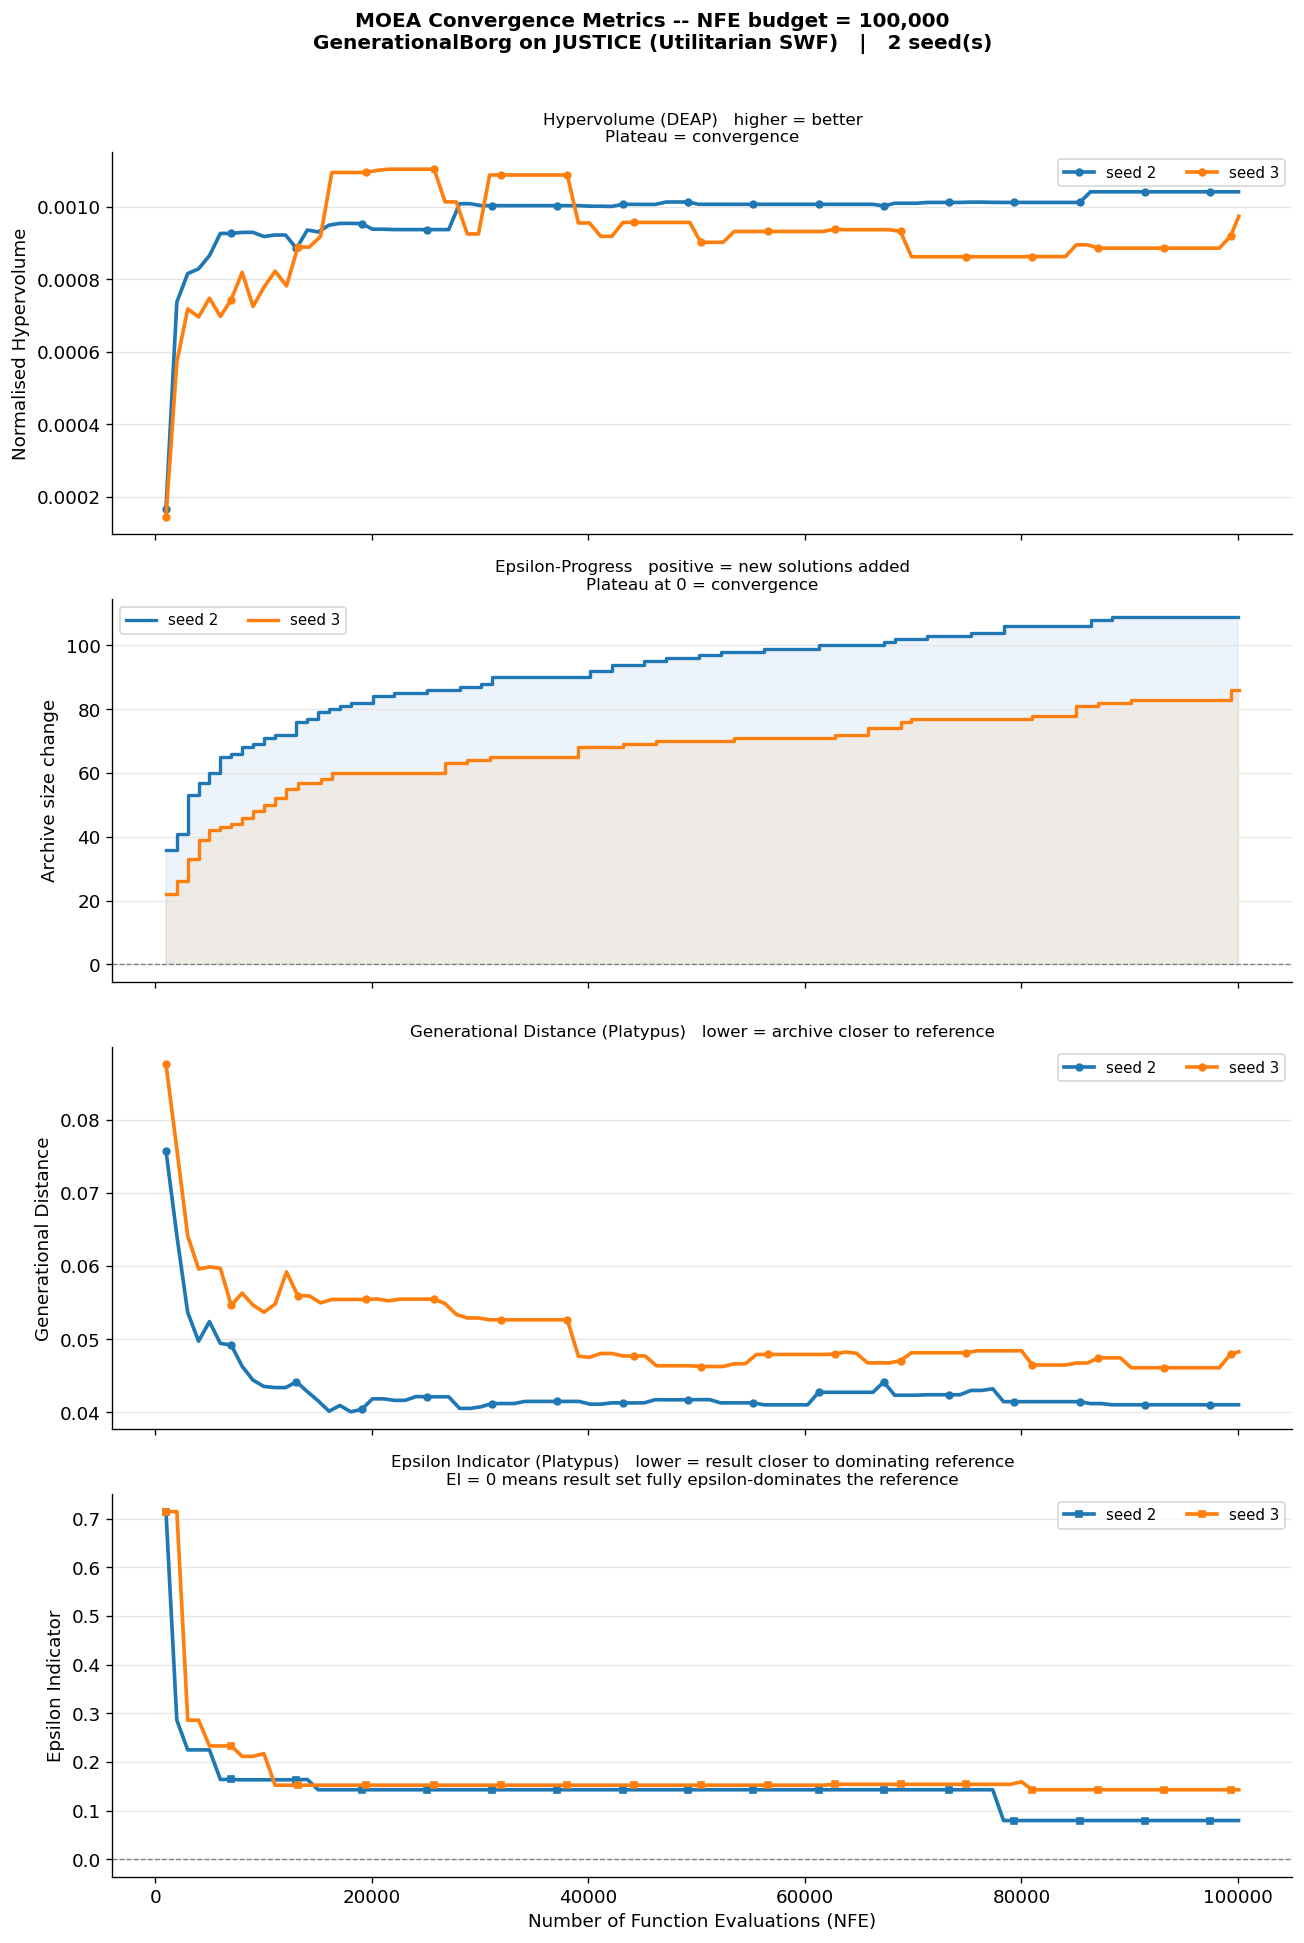

Saved: moea_convergence_metrics_100000nfe.png


In [25]:
# Four-panel convergence plot -- one figure per NFE group
if "all_metric_curves" in dir():

    nfe_budgets = sorted({nfe for (nfe, _) in all_metric_curves})
    _tab10 = plt.cm.tab10

    for nfe_budget in nfe_budgets:
        keys   = [(nfe, seed) for (nfe, seed) in sorted(all_metric_curves)
                  if nfe == nfe_budget]
        seeds  = [seed for (_, seed) in keys]
        colors = [_tab10(i / 10) for i in range(len(seeds))]

        fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=True)

        # Panel 1: Hypervolume (DEAP)
        ax = axes[0]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["hv"], lw=2.2, color=col, marker="o", markersize=4,
                    markevery=max(1, len(d["nfe"]) // 15), label=f"seed {seed}")
        ax.set_ylabel("Normalised Hypervolume", fontsize=11)
        ax.set_title("Hypervolume (DEAP)   higher = better\nPlateau = convergence", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 2: Epsilon-progress
        ax = axes[1]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            ax.plot(d["nfe"], d["eps"], lw=2.0, color=col,
                    drawstyle="steps-post", label=f"seed {seed}")
            ax.fill_between(d["nfe"], 0, d["eps"], step="post", color=col, alpha=0.08)
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Archive size change", fontsize=11)
        ax.set_title("Epsilon-Progress   positive = new solutions added\nPlateau at 0 = convergence", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 3: Generational Distance
        ax = axes[2]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["gd"])
            ax.plot(d["nfe"][mask], d["gd"][mask], lw=2.2, color=col,
                    marker="o", markersize=4,
                    markevery=max(1, mask.sum() // 15), label=f"seed {seed}")
        ax.set_ylabel("Generational Distance", fontsize=11)
        ax.set_title("Generational Distance (Platypus)   lower = archive closer to reference", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))

        # Panel 4: Epsilon Indicator
        ax = axes[3]
        for (nfe, seed), col in zip(keys, colors):
            d = all_metric_curves[(nfe, seed)]
            mask = np.isfinite(d["ei"])
            ax.plot(d["nfe"][mask], d["ei"][mask], lw=2.2, color=col,
                    marker="s", markersize=4,
                    markevery=max(1, mask.sum() // 15), label=f"seed {seed}")
        ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
        ax.set_ylabel("Epsilon Indicator", fontsize=11)
        ax.set_title("Epsilon Indicator (Platypus)   lower = result closer to dominating reference\nEI = 0 means result set fully epsilon-dominates the reference", fontsize=10)
        ax.legend(fontsize=9, ncol=min(len(seeds), 3))
        ax.set_xlabel("Number of Function Evaluations (NFE)", fontsize=11)

        for ax in axes:
            ax.grid(axis="y", color="0.9", zorder=0)

        fig.suptitle(
            f"MOEA Convergence Metrics -- NFE budget = {nfe_budget:,}\n"
            f"GenerationalBorg on JUSTICE (Utilitarian SWF)   |   {len(seeds)} seed(s)",
            fontsize=12, y=1.01, fontweight="bold",
        )
        plt.tight_layout()
        fname = f"moea_convergence_metrics_{nfe_budget}nfe.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fname}")

In [26]:
# Final metric summary table
if "all_metric_curves" in dir():
    rows = []
    for (nfe_budget, seed), d in sorted(all_metric_curves.items()):
        rows.append({
            "nfe_budget":       nfe_budget,
            "seed":             seed,
            "final_NFE":        int(d["nfe"][-1]),
            "n_snapshots":      len(d["nfe"]),
            "final_HV":         round(float(d["hv"][-1]), 5)  if np.isfinite(d["hv"][-1])  else None,
            "total_eps":        int(d["eps"].sum()),
            "final_GD":         round(float(d["gd"][-1]), 5)  if np.isfinite(d["gd"][-1])  else None,
            "final_EI":         round(float(d["ei"][-1]), 5)  if np.isfinite(d["ei"][-1])  else None,
            "eps_source":       d["eps_source"],
        })

    df_metrics = pd.DataFrame(rows)
    print("MOEA performance summary:")
    print(df_metrics.to_string(index=False))

    print("\n-- Per-NFE-group seed consistency (HV coefficient of variation) --")
    for nfe_budget, grp in df_metrics.groupby("nfe_budget"):
        hv_vals = grp["final_HV"].dropna()
        if len(hv_vals) > 1:
            cv = hv_vals.std() / hv_vals.mean() * 100
            print(f"  NFE={nfe_budget:,}: HV CV = {cv:.1f}%  "
                  f"({'high consistency' if cv < 5 else 'moderate' if cv < 20 else 'high variability'})")
        else:
            print(f"  NFE={nfe_budget:,}: only 1 seed -- no CV computable")

MOEA performance summary:
 nfe_budget  seed  final_NFE  n_snapshots  final_HV  total_eps  final_GD  final_EI    eps_source
     100000     2     100053          100   0.00104       9277   0.04105   0.07965 EMA Workbench
     100000     3     100078           98   0.00097       6654   0.04828   0.14286 EMA Workbench

-- Per-NFE-group seed consistency (HV coefficient of variation) --
  NFE=100,000: HV CV = 4.9%  (high consistency)


The convergence plots show that the optimisation improves rapidly during the early part of the run. Hypervolume increases and begins to plateau, while Generational Distance and the Epsilon Indicator decrease and remain low towards the end of the 50,000 NFE budget. This suggests that the five seeds are approaching a similar reference set and that the final Pareto archive is sufficiently stable for further analysis. The epsilon-progress panel is interpreted cautiously, because in this implementation it mainly reflects archive growth rather than a clean convergence-to-zero signal.

Seed 1 performs slightly worse in terms of final hypervolume, but the overall variation across seeds remains small.

## 5. Understand trade-offs and select candidate policies

**Project purpose:** turn the Pareto archive into policy insight.

**Main source:** Assignment 7 — Pareto visualisation.  
**Input:** combined reference set from Assignment 6.  
**Output:** trade-off plots and selected policy candidates A/B/C.

This is where the results start becoming politically useful for South Africa.

### 5.1 Pareto trade-off plots

The most relevant trade-offs for South Africa are:

1. `fraction_above_threshold` vs `welfare_loss_abatement`
2. `welfare_loss_damage` vs `welfare_loss_abatement`
3. `welfare` vs `fraction_above_threshold`

Use these plots to show that climate safety and transition burden are in tension.

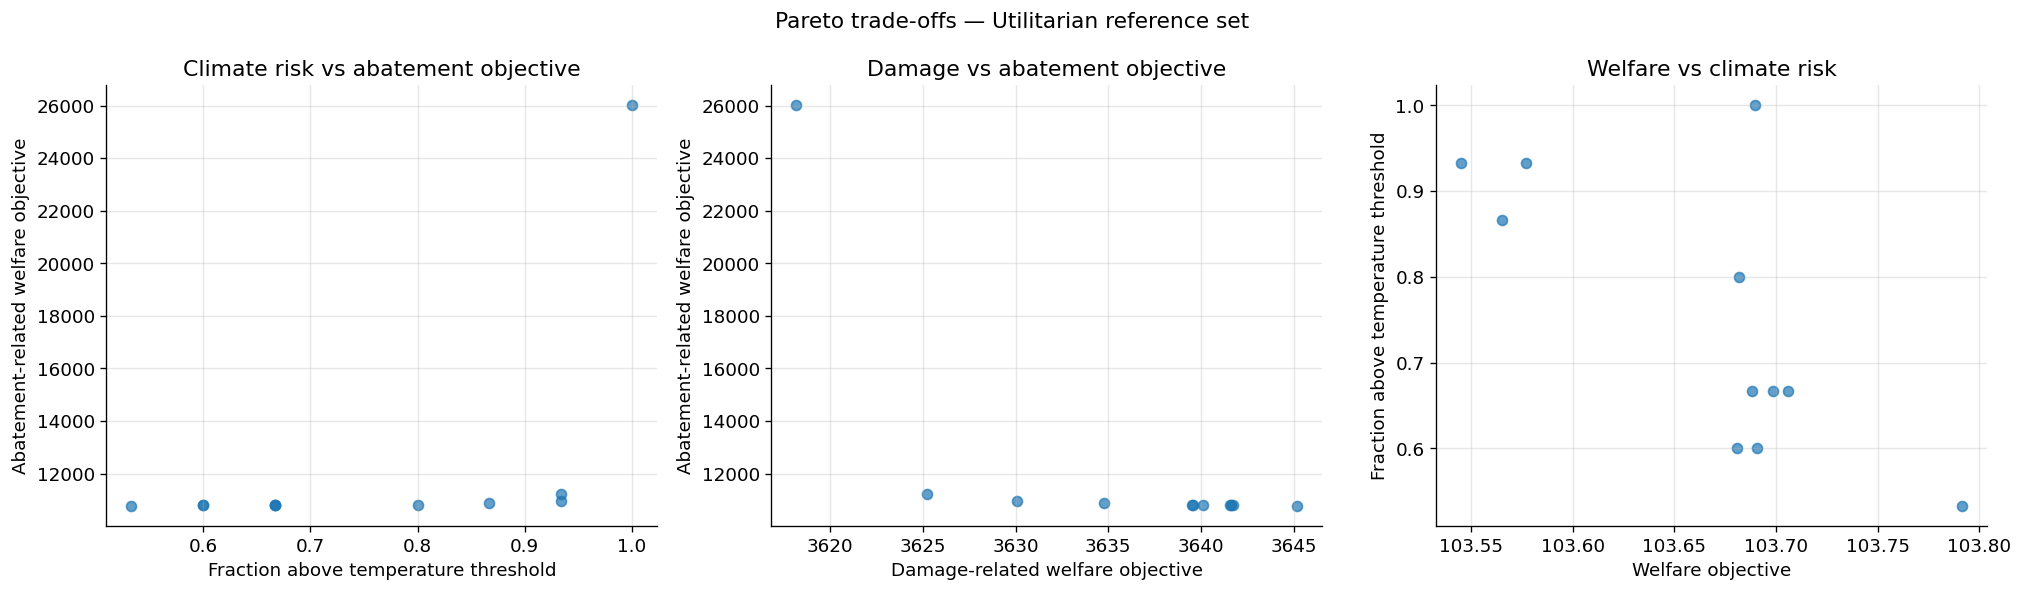

Figure saved: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots_rival/pareto_tradeoffs_utilitarian.png


In [27]:
# Step 5.1 — Pareto trade-off plots for optimisation objectives
reference_file = pd.read_csv(RESULTS_DIR / reference_set)
if reference_file is None:
    raise ValueError("No reference set loaded. Load reference_set_utilitarian.csv first.")

required = set(OBJECTIVE_COLS)
missing = required - set(reference_file.columns)

if missing:
    raise KeyError(f"Reference set is missing expected objective columns: {missing}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Climate risk vs abatement objective
axes[0].scatter(
    reference_file["fraction_above_threshold"],
    reference_file["welfare_loss_abatement"],
    alpha=0.7,
)
axes[0].set_xlabel("Fraction above temperature threshold")
axes[0].set_ylabel("Abatement-related welfare objective")
axes[0].set_title("Climate risk vs abatement objective")
axes[0].grid(True, alpha=0.3)

# 2. Damage objective vs abatement objective
axes[1].scatter(
    reference_file["welfare_loss_damage"],
    reference_file["welfare_loss_abatement"],
    alpha=0.7,
)
axes[1].set_xlabel("Damage-related welfare objective")
axes[1].set_ylabel("Abatement-related welfare objective")
axes[1].set_title("Damage vs abatement objective")
axes[1].grid(True, alpha=0.3)

# 3. Welfare vs climate risk
axes[2].scatter(
    reference_file["welfare"],
    reference_file["fraction_above_threshold"],
    alpha=0.7,
)
axes[2].set_xlabel("Welfare objective")
axes[2].set_ylabel("Fraction above temperature threshold")
axes[2].set_title("Welfare vs climate risk")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Pareto trade-offs — Utilitarian reference set", fontsize=13)
plt.tight_layout()

plot_path = PLOTS_DIR / "pareto_tradeoffs_utilitarian.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

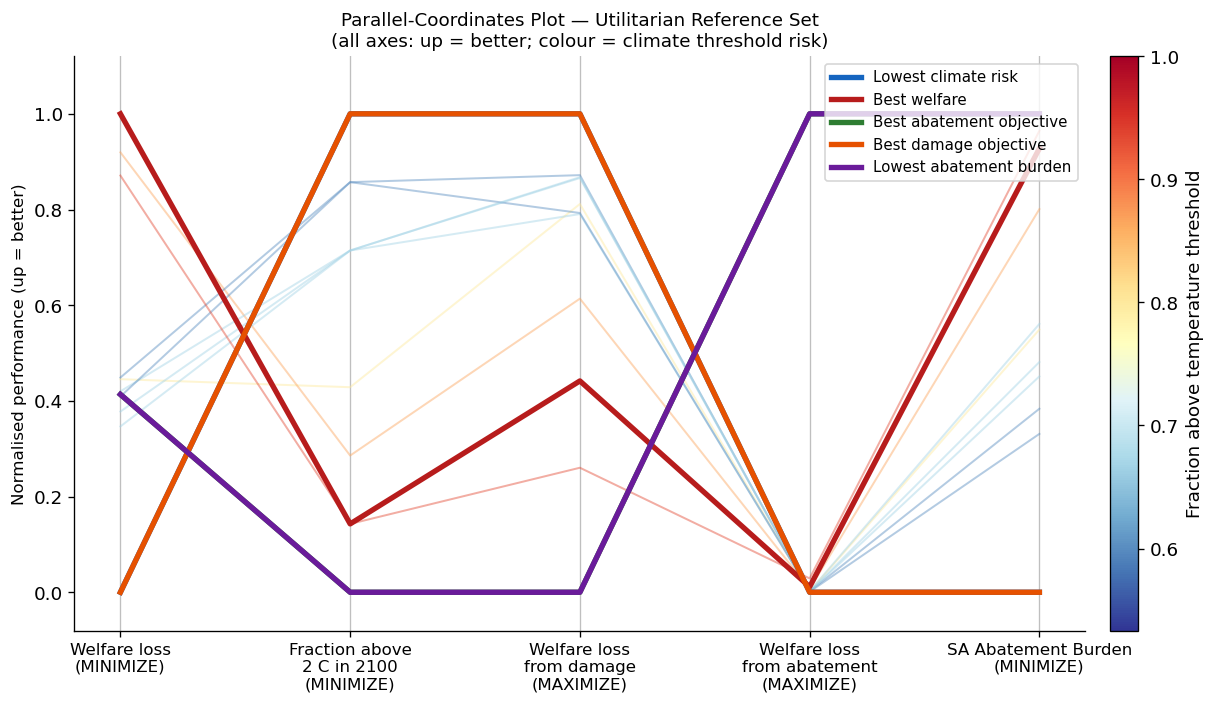

Figure saved: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots_rival/parcoords_reference_set_utilitarian.png


In [28]:
# Step 5.2 — Parallel-coordinates plot for optimisation objectives
# All axes are normalised so that up = better.

obj = reference_file[OBJECTIVE_COLS].copy()

def normalise_for_plot(df_obj):
    normed = df_obj.copy().astype(float)

    # For MINIMIZE objectives: lower is better, so invert after scaling
    for col in MINIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = 1.0 - (normed[col] - lo) / (hi - lo + 1e-15)

    # For MAXIMIZE objectives: higher is better
    for col in MAXIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = (normed[col] - lo) / (hi - lo + 1e-15)

    return normed

obj_norm = normalise_for_plot(obj)

# Four highlighted anchor policies
extremes = {
    "Lowest climate risk": obj["fraction_above_threshold"].idxmin(),
    "Best welfare": obj["welfare"].idxmin(),
    "Best abatement objective": obj["welfare_loss_abatement"].idxmax(),
    "Best damage objective": obj["welfare_loss_damage"].idxmax(),
    "Lowest abatement burden": obj["abatement_burden"].idxmin(),
}

extreme_colors = ["#1565C0", "#B71C1C", "#2E7D32", "#E65100","#6A1B9A" ]

fig, ax = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(OBJECTIVE_COLS))
axis_labels = [OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS]

# Colour all lines by original climate risk
risk_vals = obj["fraction_above_threshold"].values
cmap_risk = plt.cm.RdYlBu_r
norm_risk = Normalize(vmin=risk_vals.min(), vmax=risk_vals.max())

# Plot all reference-set policies
for idx, row in obj_norm.iterrows():
    y = row[OBJECTIVE_COLS].values
    color = cmap_risk(norm_risk(obj.loc[idx, "fraction_above_threshold"]))
    ax.plot(x_pos, y, color=color, lw=1.2, alpha=0.45, zorder=2)

# Highlight anchor policies
handles = []

for (label, idx), ec in zip(extremes.items(), extreme_colors):
    h, = ax.plot(
        x_pos,
        obj_norm.loc[idx, OBJECTIVE_COLS].values,
        color=ec,
        lw=3.2,
        label=label,
        zorder=5,
    )
    handles.append(h)

# Axis styling
for xi in x_pos:
    ax.axvline(xi, color="0.75", lw=0.8, zorder=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_ylabel("Normalised performance (up = better)", fontsize=10)
ax.set_ylim(-0.08, 1.12)

ax.set_title(
    "Parallel-Coordinates Plot — Utilitarian Reference Set\n"
    "(all axes: up = better; colour = climate threshold risk)",
    fontsize=11,
)

ax.legend(handles=handles, loc="upper right", fontsize=9)

# Colourbar
sm = plt.cm.ScalarMappable(cmap=cmap_risk, norm=norm_risk)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Fraction above temperature threshold")

plt.tight_layout()

plot_path = PLOTS_DIR / "parcoords_reference_set_utilitarian.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved:", plot_path)

In [29]:

# ── Model constants ─────────────────────────

#TODO:
#Before you begin: Update the path in the cell below
#to point to the config file you created previously.
#Make sure it reflects the scenario and settings you have been working
#with throughout.

with open(os.path.join(_PROJECT_DIR, "../config/config_student.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year            = _cfg["start_year"],
    end_year              = _cfg["end_year"],
    data_timestep         = _cfg["data_timestep"],
    timestep              = _cfg["timestep"],
)
N_TIMESTEPS    = len(_time_horizon.model_time_horizon)
N_REGIONS      = len(DataLoader().REGION_LIST)
REGION_LIST    = list(DataLoader().REGION_LIST)
N_INPUTS_RBF   = _cfg["n_inputs"]
N_RBFS         = _cfg["n_inputs"] + 2
SCENARIO       = _cfg["reference_ssp_rcp_scenario_index"]
EC_START_TS    = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

# ── Helper: run JUSTICE for one policy row ────────────────────────────────────
def run_policy_ecr(policy_row, n_ensemble=1):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center {i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii {i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights {i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = 0.0
    diff      = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)
    return ecr_mean, datasets



In [30]:
# Step 5.3 — Reconstruct ECR pathways for selected policies

# ── Select your policies ────────────────────────────────────
# Use the same policies you highlighted in your parallel-coordinates plot.

ref_set = reference_file.copy()
obj_ref = ref_set[OBJECTIVE_COLS]

idx_1 = obj_ref["fraction_above_threshold"].idxmin()
idx_2 = obj_ref["welfare"].idxmin()
idx_3 = obj_ref["welfare_loss_abatement"].idxmax()
idx_4 = obj_ref["welfare_loss_damage"].idxmax()
idx_5 = obj_ref["abatement_burden"].idxmin()

anchors = {
    "Policy 1 — lowest climate risk": idx_1,
    "Policy 2 — best welfare": idx_2,
    "Policy 3 — best abatement objective": idx_3,
    "Policy 4 — best damage objective": idx_4,
    "Policy 5 — lowest abatement burden": idx_5,
}

print("Selected policies from Pareto reference set:\n")

for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

# ── Run JUSTICE for each anchor ───────────────────────────────────────────────

print("Running JUSTICE model for all selected policies ...")

ecr_1, data_1 = run_policy_ecr(ref_set.loc[idx_1], n_ensemble=15)
ecr_2, data_2 = run_policy_ecr(ref_set.loc[idx_2], n_ensemble=15)
ecr_3, data_3 = run_policy_ecr(ref_set.loc[idx_3], n_ensemble=15)
ecr_4, data_4 = run_policy_ecr(ref_set.loc[idx_4], n_ensemble=15)
ecr_5, data_5 = run_policy_ecr(ref_set.loc[idx_5], n_ensemble=15)

print("Done.")

Selected policies from Pareto reference set:

  Policy 1 — lowest climate risk
welfare                       103.791
fraction_above_threshold        0.533
welfare_loss_damage          3645.174
welfare_loss_abatement      10780.333
abatement_burden                0.013

  Policy 2 — best welfare
welfare                       103.545
fraction_above_threshold        0.933
welfare_loss_damage          3630.098
welfare_loss_abatement      10953.182
abatement_burden                0.001

  Policy 3 — best abatement objective
welfare                       103.690
fraction_above_threshold        1.000
welfare_loss_damage          3618.171
welfare_loss_abatement      26006.790
abatement_burden                0.000

  Policy 4 — best damage objective
welfare                       103.791
fraction_above_threshold        0.533
welfare_loss_damage          3645.174
welfare_loss_abatement      10780.333
abatement_burden                0.013

  Policy 5 — lowest abatement burden
welfare              

In [31]:

_rice50_dict_path = os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(_rice50_dict_path) as _f:
    _rice50_dict = json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France":     "fra",
    "Norway":     "nor",
    "Kosovo":     "oeu",
    "N. Cyprus":  "tur",
    "Somaliland": "rsaf",
}

# ── Extract end-of-horizon ECR snapshot ───────────────────────────────────────
t_end     = ecr_1.shape[1] - 1
snap_year = int(_time_horizon.model_time_horizon[t_end])
print(f"End-of-horizon snapshot: timestep {t_end} = year {snap_year}")

def _snap_end(arr):
    return {REGION_LIST[i]: arr[i, t_end] for i in range(N_REGIONS)}

# TODO: replace the keys with your own policy labels (must match what you used above)
ecr_end = {
    "Policy 1 — lowest climate risk": _snap_end(ecr_1),
    "Policy 2 — best welfare": _snap_end(ecr_2),
    "Policy 3 — best abatement objective": _snap_end(ecr_3),
    "Policy 4 — best damage objective": _snap_end(ecr_4),
    "Policy 5 — lowest abatement burden": _snap_end(ecr_5),
}

# ── Load world shapefile and assign regions ───────────────────────────────────
_pyogrio_path = Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(_pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")
world = gpd.read_file(_ne_shp)

world["rice50"] = world["iso_a3"].map(iso_to_rice50)
mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = world.loc[mask_missing, "name"].map(_name_fallback)

for policy, region_ecr in ecr_end.items():
    world[f"ecr_{policy}"] = world["rice50"].map(region_ecr)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# ── Dissolve into 57 RICE50 region polygons ───────────────────────────────────
ecr_cols_map = [f"ecr_{p}" for p in ecr_end.keys()]

regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols_map]

import geopandas as _gpd
if not isinstance(regions_gdf, _gpd.GeoDataFrame):
    regions_gdf = _gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")


End-of-horizon snapshot: timestep 285 = year 2300
Countries mapped to RICE50 regions: 177/177
Dissolved to 57 RICE50 regions


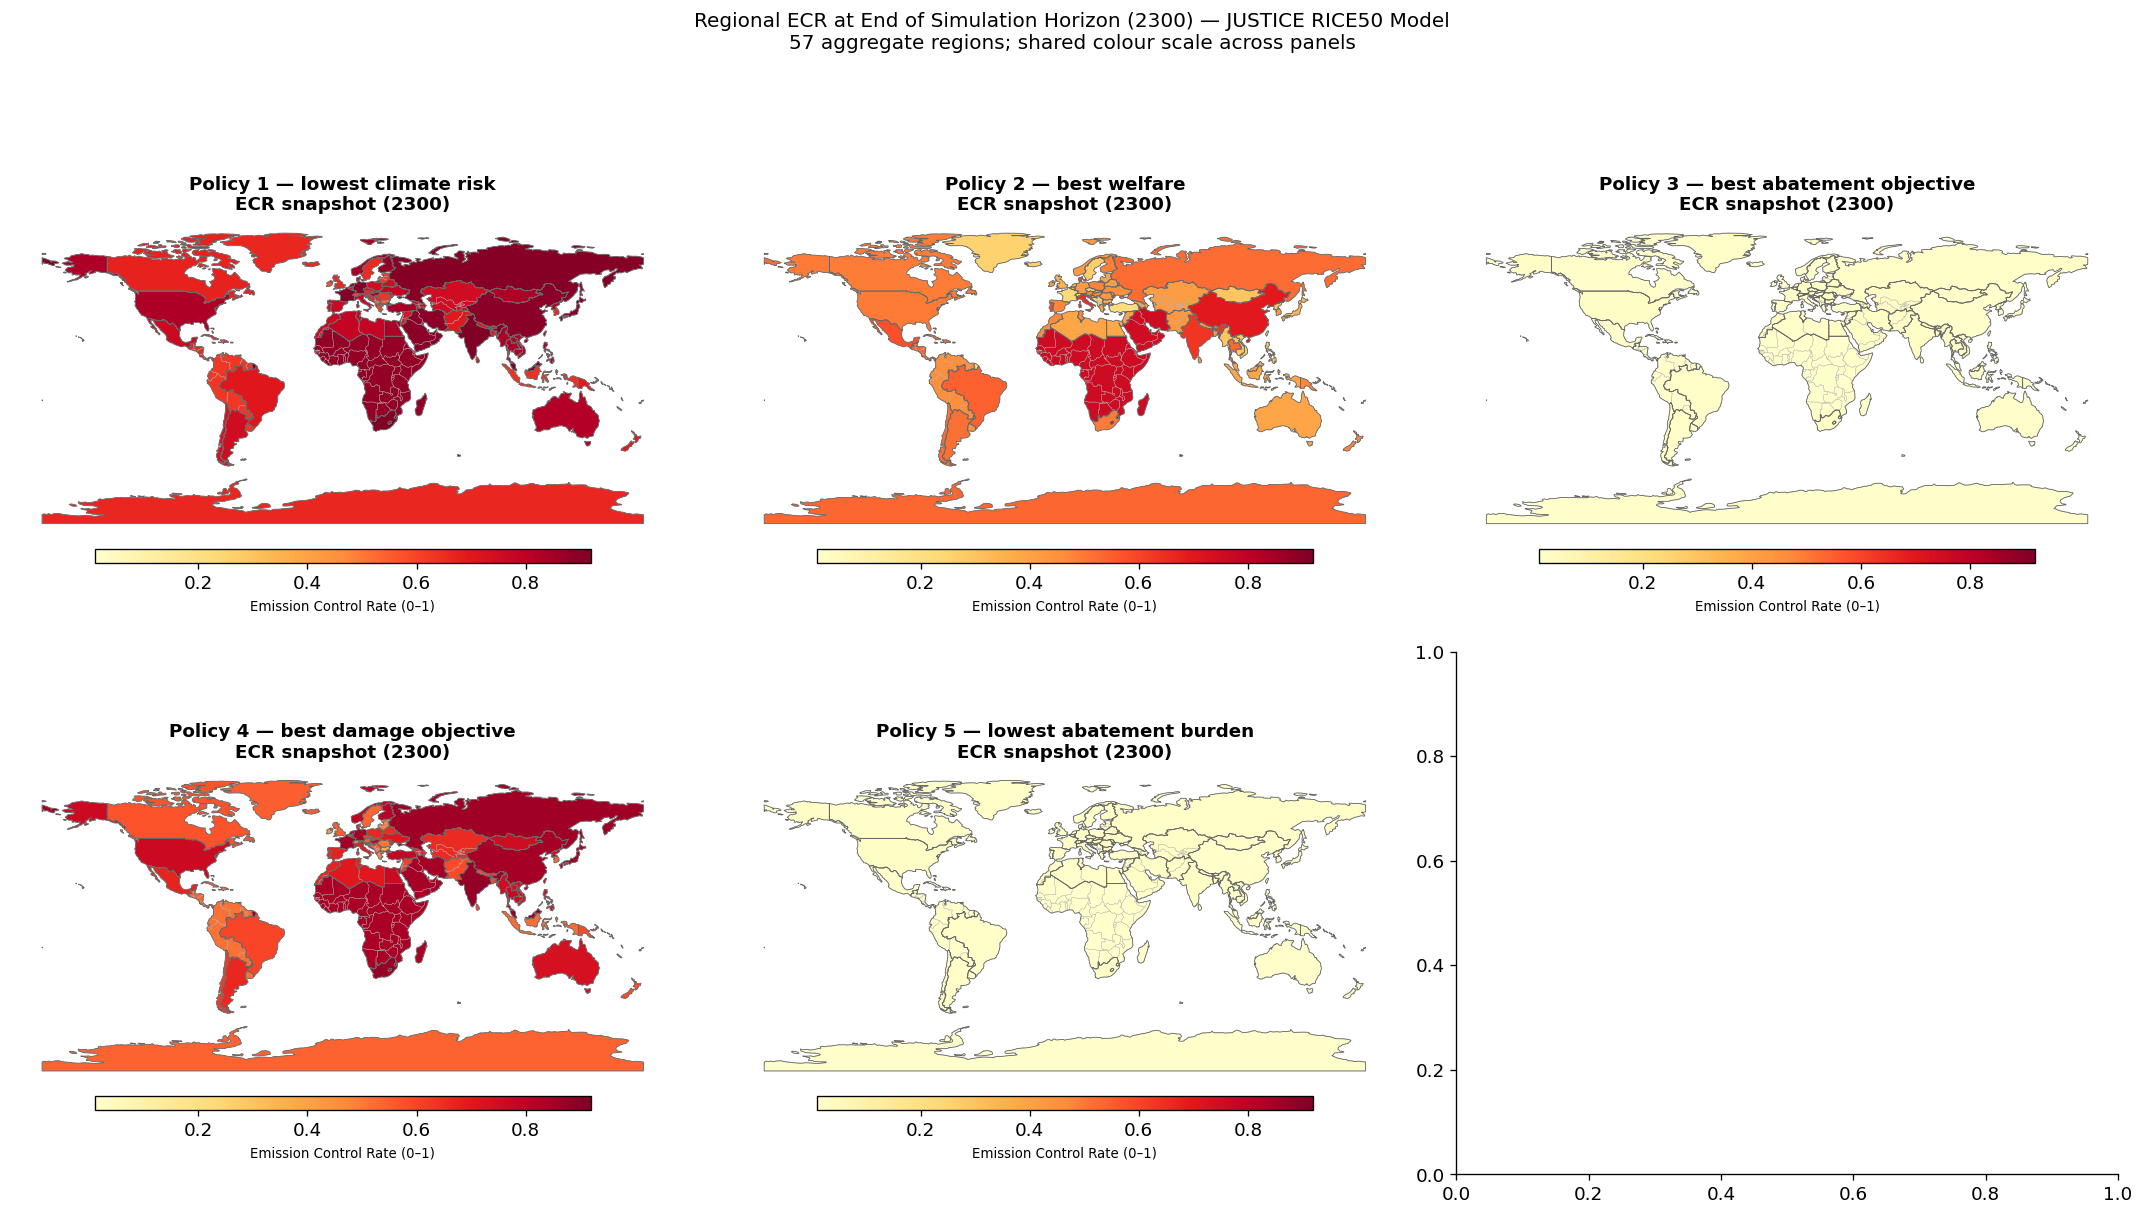

In [32]:
# ── World map — end-of-horizon ECR snapshot (2×2 grid, one panel per policy) ──
panel_specs = [
    (f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})")
    for label in ecr_end.keys()
]

all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])
vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]
    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                        pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

# TODO: update the title if needed
fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) — JUSTICE RICE50 Model\n"
    "57 aggregate regions; shared colour scale across panels",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ecr_regional_map.png"), dpi=150, bbox_inches="tight")
plt.show()
# print("Figure saved: ecr_regional_map.png")



### Trade-off Discussion

1. **Pairwise trade-offs** — for each pair of adjacent axes, does a crossing appear? What does it mean for the relationship between those two objectives?
2. **Dominant trade-off** — which pair shows the sharpest conflict?
3. **Synthesis** — in 2 sentences, what is the fundamental tension in this problem as revealed by the Pareto front?


# Robustness

In [33]:

# ── Patch matplotlib Path deepcopy ────────────────────────────────────────────
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# ── Objectives ────────────────────────────────────────────────────────────────
OBJECTIVES = ["welfare", "fraction_above_threshold", "welfare_loss_damage", "welfare_loss_abatement", "abatement_burden"]
OBJ_LABELS = ["Welfare", "fraction > 2C", "WL Damage", "WL Abatement", "A_Burden"]


In [34]:
N_OBJECTIVES = len(OBJECTIVES)
RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "reeval_utilitarian_177p_1000s.npy"
)
sat_score = np.nanmean(SA_SATISFICING.min(axis=2), axis=1)
results = np.load(RESULTS_PATH)

policy_objective_rates = np.nanmean(SA_SATISFICING, axis=1)

heatmap_df = pd.DataFrame(
    policy_objective_rates,
    columns=OBJECTIVES,
    index=[f"P{i}" for i in range(results.shape[0])]
)

heatmap_df["joint_sat"] = sat_score
heatmap_df = heatmap_df.sort_values("joint_sat", ascending=False)

plt.figure(figsize=(10, max(6, 0.3 * results.shape[0])))
sns.heatmap(
    heatmap_df[OBJECTIVES],
    vmin=0,
    vmax=1,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.xlabel("Objective")
plt.ylabel("Policy")
plt.title("Per-objective satisficing rate by policy")
plt.tight_layout()
plt.show()

NameError: name 'SA_SATISFICING' is not defined

In [35]:
# ============================================================
# SOUTH AFRICA ROBUSTNESS ANALYSIS
# 4 HARD SATISFICING CRITERIA + SOFT WELFARE LOSS EQUITY CHECK
# For file: reeval_utilitarian_zafmetrics_11p_1000s.npy
# Shape expected: 11 policies x 1000 scenarios x 5 metrics
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. LOAD NPY FILE
# ------------------------------------------------------------

results_path = os.path.join(
    RESULTS_DIR,
    "reeval_utilitarian_zafmetrics_11p_1000s.npy"
)

loaded_results = np.load(results_path, allow_pickle=True)

print("Loaded type:", type(loaded_results))
print("Loaded dtype:", getattr(loaded_results, "dtype", None))
print("Loaded shape:", getattr(loaded_results, "shape", None))

if not isinstance(loaded_results, np.ndarray):
    raise TypeError("Expected loaded_results to be a numpy array.")

if loaded_results.ndim != 3:
    raise ValueError(
        f"Expected a 3D array with shape (policies, scenarios, metrics), "
        f"but got shape {loaded_results.shape}."
    )

n_policies, n_scenarios, n_metrics = loaded_results.shape

if n_metrics != 10:
    raise ValueError(
        f"Expected 10 metrics in the last dimension, but got {n_metrics}. "
        "Check whether you loaded the new npy with temperature metrics."
    )

RAW_METRIC_NAMES = [
    "welfare",
    "fraction_above_threshold",
    "global_temperature_2100",
    "max_global_temperature",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_mean_net_output_ratio",
]

flat_results = loaded_results.reshape(n_policies * n_scenarios, n_metrics)

robust_df = pd.DataFrame(
    flat_results,
    columns=RAW_METRIC_NAMES
)
# ------------------------------------------------------------
# 1. CONVERT 3D ARRAY TO LONG DATAFRAME
# ------------------------------------------------------------

# IMPORTANT:
# This npy file does not store column names.
# The following mapping must match the order in which you saved the 5 metrics.
#
# Based on the values in your uploaded npy:
# - metric_0 looks like a welfare / model outcome value
# - metric_1 is fraction_above_threshold, and is 1.0 for all runs in this file
# - metric_2 looks like zaf abatement cost
# - metric_3 looks like zaf gross economic output
# - metric_4 is kept as welfare_loss_or_damage_metric for the soft diagnostic
#
# If your saving order was different, change these names here.


flat_results = loaded_results.reshape(n_policies * n_scenarios, n_metrics)

robust_df = pd.DataFrame(flat_results, columns=RAW_METRIC_NAMES)

robust_df.insert(
    0,
    "policy_id",
    np.repeat(np.arange(n_policies), n_scenarios)
)

robust_df.insert(
    1,
    "scenario_id",
    np.tile(np.arange(n_scenarios), n_policies)
)

policy_col = "policy_id"

print("robust_df created.")
print("Shape:", robust_df.shape)
print("Columns:", robust_df.columns.tolist())
display(robust_df.head())


# ------------------------------------------------------------
# 2. CREATE SOUTH AFRICA DERIVED METRICS
# ------------------------------------------------------------

# In this npy file, damage_fraction and net_output_ratio do not appear to be stored
# as directly named separate columns. Therefore, this block only creates them if
# the necessary raw columns are available. Otherwise, it warns clearly.

if {
    "zaf_economic_damage",
    "zaf_gross_economic_output"
}.issubset(robust_df.columns):

    robust_df["zaf_mean_damage_fraction"] = (
        robust_df["zaf_economic_damage"]
        / robust_df["zaf_gross_economic_output"].replace(0, np.nan)
    )

if {
    "zaf_net_economic_output",
    "zaf_gross_economic_output"
}.issubset(robust_df.columns):

    robust_df["zaf_mean_net_output_ratio"] = (
        robust_df["zaf_net_economic_output"]
        / robust_df["zaf_gross_economic_output"].replace(0, np.nan)
    )


# ------------------------------------------------------------
# 3. DEFINE SOUTH AFRICA SATISFICING CRITERIA
# ------------------------------------------------------------

# Start with the criteria that can definitely be calculated from this npy.
SA_SATISFICING = {
    "fraction_above_threshold": ("<=", 0.25),
    "zaf_mean_abatement_burden": ("<=", 0.05),
    "zaf_mean_damage_fraction": ("<=", 0.05),
    "zaf_mean_net_output_ratio": (">=", 0.92),
}
# Add damage fraction only if it exists
if "zaf_mean_damage_fraction" in robust_df.columns:
    SA_SATISFICING["zaf_mean_damage_fraction"] = ("<=", 0.05)
else:
    print(
        "WARNING: zaf_mean_damage_fraction is not in this npy file, "
        "so it cannot be used as a hard satisficing criterion in this cell."
    )

# Add net output ratio only if it exists
if "zaf_mean_net_output_ratio" in robust_df.columns:
    SA_SATISFICING["zaf_mean_net_output_ratio"] = (">=", 0.92)
else:
    print(
        "WARNING: zaf_mean_net_output_ratio is not in this npy file, "
        "so it cannot be used as a hard satisficing criterion in this cell."
    )

print("Using satisficing criteria:")
print(SA_SATISFICING)


# ------------------------------------------------------------
# 4. APPLY SATISFICING CRITERIA
# ------------------------------------------------------------

def check_criterion(series, operator, threshold):
    if operator == "<=":
        return series <= threshold
    elif operator == ">=":
        return series >= threshold
    else:
        raise ValueError(f"Unsupported operator: {operator}")

for outcome, (operator, threshold) in SA_SATISFICING.items():
    robust_df[f"satisficing_{outcome}"] = check_criterion(
        robust_df[outcome],
        operator,
        threshold
    )

satisficing_cols = [
    f"satisficing_{outcome}"
    for outcome in SA_SATISFICING
]

robust_df["sa_satisficing"] = robust_df[satisficing_cols].all(axis=1)

print("Created satisficing columns:")
print(satisficing_cols)

print("Overall share of satisficing runs:")
print(robust_df["sa_satisficing"].mean())


# ------------------------------------------------------------
# 5. CALCULATE ROBUSTNESS SCORE PER POLICY
# ------------------------------------------------------------

agg_dict = {
    "robustness_score": ("sa_satisficing", "mean"),
    "n_scenarios": ("sa_satisficing", "size"),
    "n_satisficing": ("sa_satisficing", "sum"),
    "mean_fraction_above_threshold": ("fraction_above_threshold", "mean"),
    "mean_zaf_abatement_burden": ("zaf_mean_abatement_burden", "mean"),
    "mean_welfare": ("welfare", "mean"),
}

if "zaf_mean_damage_fraction" in robust_df.columns:
    agg_dict["mean_zaf_damage_fraction"] = ("zaf_mean_damage_fraction", "mean")

if "zaf_mean_net_output_ratio" in robust_df.columns:
    agg_dict["mean_zaf_net_output_ratio"] = ("zaf_mean_net_output_ratio", "mean")

sa_robustness = (
    robust_df
    .groupby(policy_col)
    .agg(
        robustness_score=("sa_satisficing", "mean"),
        n_scenarios=("sa_satisficing", "size"),
        n_satisficing=("sa_satisficing", "sum"),
        mean_fraction_above_threshold=("fraction_above_threshold", "mean"),
        mean_zaf_abatement_burden=("zaf_mean_abatement_burden", "mean"),
        mean_zaf_damage_fraction=("zaf_mean_damage_fraction", "mean"),
        mean_zaf_net_output_ratio=("zaf_mean_net_output_ratio", "mean"),
        mean_welfare=("welfare", "mean"),
        mean_welfare_loss_damage=("welfare_loss_damage", "mean"),
        mean_welfare_loss_abatement=("welfare_loss_abatement", "mean"),
        mean_global_abatement_burden=("abatement_burden", "mean"),
    )
    .reset_index()
)

sa_robustness = sa_robustness.sort_values(
    by="robustness_score",
    ascending=False
)

print("Top policies based on hard SA satisficing robustness:")
display(sa_robustness.head(20))


# ------------------------------------------------------------
# 6. SOFT EQUITY / WELFARE LOSS DIAGNOSTIC
# ------------------------------------------------------------

# Welfare loss is not used as a hard satisficing filter.
# It is used only as a soft diagnostic after the 4 hard SA criteria.

sa_policy_summary = sa_robustness.copy()

sa_policy_summary["mean_total_welfare_loss"] = (
    sa_policy_summary["mean_welfare_loss_damage"]
    + sa_policy_summary["mean_welfare_loss_abatement"]
)

sa_policy_summary = sa_policy_summary.sort_values(
    by=[
        "robustness_score",
        "mean_zaf_abatement_burden",
        "mean_total_welfare_loss",
    ],
    ascending=[False, True, True]
)

print("Final South Africa policy summary:")
display(sa_policy_summary.head(20))
# ------------------------------------------------------------
# 7. OPTIONAL: SELECT POLICIES ABOVE A ROBUSTNESS THRESHOLD
# ------------------------------------------------------------

ROBUSTNESS_THRESHOLD = 0.70

sa_acceptable_policies = sa_policy_summary[
    sa_policy_summary["robustness_score"] >= ROBUSTNESS_THRESHOLD
].copy()

print(f"Number of policies with robustness_score >= {ROBUSTNESS_THRESHOLD}:")
print(len(sa_acceptable_policies))

display(sa_acceptable_policies.head(20))


# ------------------------------------------------------------
# 8. EXPORT RESULTS
# ------------------------------------------------------------

summary_csv = os.path.join(
    RESULTS_DIR,
    "sa_satisficing_robustness_with_soft_metric.csv"
)

summary_tex = os.path.join(
    RESULTS_DIR,
    "sa_satisficing_robustness_with_soft_metric.tex"
)

sa_policy_summary.to_csv(summary_csv, index=False)

sa_policy_summary.head(20).to_latex(
    summary_tex,
    index=False,
    float_format="%.3f"
)

print("Exported:")
print(summary_csv)
print(summary_tex)

Loaded type: <class 'numpy.ndarray'>
Loaded dtype: float64
Loaded shape: (11, 1000, 10)
robust_df created.
Shape: (11000, 12)
Columns: ['policy_id', 'scenario_id', 'welfare', 'fraction_above_threshold', 'global_temperature_2100', 'max_global_temperature', 'welfare_loss_damage', 'welfare_loss_abatement', 'abatement_burden', 'zaf_mean_abatement_burden', 'zaf_mean_damage_fraction', 'zaf_mean_net_output_ratio']


,policy_id,scenario_id,welfare,fraction_above_threshold,global_temperature_2100,max_global_temperature,welfare_loss_damage,welfare_loss_abatement,abatement_burden,zaf_mean_abatement_burden,zaf_mean_damage_fraction,zaf_mean_net_output_ratio
0,0,0,103.737617,1.0,3.671216,6.376897,3573.695993,26006.789543,4.802261e-07,1.405280e-07,0.077584,0.922416
1,0,1,103.378830,1.0,2.508663,4.350915,5309.648513,26006.789543,4.780966e-07,1.401389e-07,0.043330,0.956669
2,0,2,104.143917,1.0,4.731481,11.562779,3621.530979,26006.789543,4.822879e-07,1.407598e-07,0.146933,0.853067
3,0,3,104.403644,1.0,5.240038,13.274767,3569.728757,26006.789543,4.837548e-07,1.410385e-07,0.174831,0.825169
4,0,4,103.753159,1.0,3.646947,7.162489,4093.231540,26006.789543,4.802246e-07,1.404964e-07,0.087949,0.912051


Using satisficing criteria:
{'fraction_above_threshold': ('<=', 0.25), 'zaf_mean_abatement_burden': ('<=', 0.05), 'zaf_mean_damage_fraction': ('<=', 0.05), 'zaf_mean_net_output_ratio': ('>=', 0.92)}
Created satisficing columns:
['satisficing_fraction_above_threshold', 'satisficing_zaf_mean_abatement_burden', 'satisficing_zaf_mean_damage_fraction', 'satisficing_zaf_mean_net_output_ratio']
Overall share of satisficing runs:
0.35363636363636364
Top policies based on hard SA satisficing robustness:


,policy_id,robustness_score,n_scenarios,n_satisficing,mean_fraction_above_threshold,mean_zaf_abatement_burden,mean_zaf_damage_fraction,mean_zaf_net_output_ratio,mean_welfare,mean_welfare_loss_damage,mean_welfare_loss_abatement,mean_global_abatement_burden
3,3,0.586,1000,586,0.414,1.154097e-02,0.017473,0.970986,103.756107,4323.121842,10785.121467,1.244871e-02
8,8,0.516,1000,516,0.484,5.546118e-03,0.024531,0.969923,103.687572,4329.480014,10812.732942,9.001280e-03
7,7,0.508,1000,508,0.492,4.644898e-03,0.024488,0.970867,103.680417,4243.984701,10813.843108,6.629367e-03
9,9,0.493,1000,493,0.507,9.935905e-04,0.022718,0.976289,103.677104,4217.480220,10800.812959,7.247086e-03
5,5,0.484,1000,484,0.516,1.032133e-02,0.023661,0.966017,103.658316,4214.182091,10803.860643,6.725680e-03
1,1,0.427,1000,427,0.573,1.077693e-02,0.025375,0.963848,103.642576,4206.779289,10808.032214,5.456346e-03
4,4,0.385,1000,385,0.615,4.232115e-03,0.027753,0.968015,103.603746,4203.925888,10827.622074,4.852826e-03
2,2,0.291,1000,291,0.709,4.663767e-04,0.034668,0.964865,103.534163,4197.109620,10880.200498,2.621682e-03
6,6,0.140,1000,140,0.860,3.199944e-04,0.043870,0.955810,103.511233,4191.333108,10949.987380,9.446429e-04
10,10,0.055,1000,55,0.945,6.315810e-05,0.056584,0.943353,103.536815,4184.951835,11223.093492,4.758324e-04


Final South Africa policy summary:


,policy_id,robustness_score,n_scenarios,n_satisficing,mean_fraction_above_threshold,mean_zaf_abatement_burden,mean_zaf_damage_fraction,mean_zaf_net_output_ratio,mean_welfare,mean_welfare_loss_damage,mean_welfare_loss_abatement,mean_global_abatement_burden,mean_total_welfare_loss
3,3,0.586,1000,586,0.414,1.154097e-02,0.017473,0.970986,103.756107,4323.121842,10785.121467,1.244871e-02,15108.243310
8,8,0.516,1000,516,0.484,5.546118e-03,0.024531,0.969923,103.687572,4329.480014,10812.732942,9.001280e-03,15142.212956
7,7,0.508,1000,508,0.492,4.644898e-03,0.024488,0.970867,103.680417,4243.984701,10813.843108,6.629367e-03,15057.827810
9,9,0.493,1000,493,0.507,9.935905e-04,0.022718,0.976289,103.677104,4217.480220,10800.812959,7.247086e-03,15018.293179
5,5,0.484,1000,484,0.516,1.032133e-02,0.023661,0.966017,103.658316,4214.182091,10803.860643,6.725680e-03,15018.042734
1,1,0.427,1000,427,0.573,1.077693e-02,0.025375,0.963848,103.642576,4206.779289,10808.032214,5.456346e-03,15014.811503
4,4,0.385,1000,385,0.615,4.232115e-03,0.027753,0.968015,103.603746,4203.925888,10827.622074,4.852826e-03,15031.547962
2,2,0.291,1000,291,0.709,4.663767e-04,0.034668,0.964865,103.534163,4197.109620,10880.200498,2.621682e-03,15077.310118
6,6,0.140,1000,140,0.860,3.199944e-04,0.043870,0.955810,103.511233,4191.333108,10949.987380,9.446429e-04,15141.320487
10,10,0.055,1000,55,0.945,6.315810e-05,0.056584,0.943353,103.536815,4184.951835,11223.093492,4.758324e-04,15408.045327


Number of policies with robustness_score >= 0.7:
0


,policy_id,robustness_score,n_scenarios,n_satisficing,mean_fraction_above_threshold,mean_zaf_abatement_burden,mean_zaf_damage_fraction,mean_zaf_net_output_ratio,mean_welfare,mean_welfare_loss_damage,mean_welfare_loss_abatement,mean_global_abatement_burden,mean_total_welfare_loss


Exported:
/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/sa_satisficing_robustness_with_soft_metric.csv
/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/sa_satisficing_robustness_with_soft_metric.tex


In [36]:
# ============================================================
# RIVAL FRAMING PLOTS — SOUTH AFRICA
# UTILITARIAN OUTCOMES ONLY
# Updated for literal temperature criterion
# Expected npy shape: policies x scenarios x 10 metrics
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

FRAMING_NAME = "Utilitarian rival framing"
ACTOR_NAME = "South Africa"

# Use corrected re-evaluation file
INPUT_FILE = os.path.join(
    RESULTS_DIR,
    "reeval_utilitarian_zafmetrics_11p_1000s.npy"
)

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "rival_framing_plots_south_africa_utilitarian_temperature"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# IMPORTANT:
# This order must match the return order in run_reeval_uti.py
RAW_METRIC_NAMES = [
    "welfare",
    "fraction_above_threshold",
    "global_temperature_2100",
    "max_global_temperature",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_mean_net_output_ratio",
]

# ============================================================
# SOUTH AFRICA SATISFICING CRITERIA
# ============================================================

# All thresholds should be changed ONLY here.
# The rest of the code automatically follows these values.
SA_CRITERIA = {
    "global_temperature_2100": ("<=", 1.5),
    "zaf_mean_abatement_burden": ("<=", 0.05),
    "zaf_mean_damage_fraction": ("<=", 0.05),
    "zaf_mean_net_output_ratio": (">=", 0.95),
}

# Diagnostic old 2°C exceedance criterion.
# This is not part of the main SA robustness score.
DIAGNOSTIC_CRITERIA = {
    "fraction_above_threshold": ("<=", 0.25),
}

# Extract thresholds automatically from SA_CRITERIA
TEMP_THRESHOLD = SA_CRITERIA["global_temperature_2100"][1]
BURDEN_THRESHOLD = SA_CRITERIA["zaf_mean_abatement_burden"][1]
DAMAGE_THRESHOLD = SA_CRITERIA["zaf_mean_damage_fraction"][1]
NET_OUTPUT_THRESHOLD = SA_CRITERIA["zaf_mean_net_output_ratio"][1]

TOP_N = 11
N_SELECTED_POLICIES = 4


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def savefig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.close()
    return path


def apply_criteria(df, criteria, prefix):
    """
    Applies all satisficing criteria to a dataframe.

    For each criterion, creates a boolean pass/fail column.
    Also creates one aggregate column showing whether all criteria are met.
    """
    cols = []

    for outcome, (operator, threshold) in criteria.items():
        col_name = f"{prefix}_{outcome}"

        if outcome not in df.columns:
            raise KeyError(f"Outcome '{outcome}' not found in dataframe.")

        if operator == "<=":
            df[col_name] = df[outcome] <= threshold
        elif operator == ">=":
            df[col_name] = df[outcome] >= threshold
        else:
            raise ValueError(f"Unsupported operator: {operator}")

        cols.append(col_name)

    df[f"{prefix}_all"] = df[cols].all(axis=1)
    return df, cols


def criterion_label(outcome, operator, threshold):
    """
    Creates readable labels for plots.
    """
    if outcome == "global_temperature_2100":
        return f"Global temperature 2100 {operator} {threshold}°C"
    elif outcome == "zaf_mean_abatement_burden":
        return f"SA abatement burden {operator} {threshold}"
    elif outcome == "zaf_mean_damage_fraction":
        return f"SA damage fraction {operator} {threshold}"
    elif outcome == "zaf_mean_net_output_ratio":
        return f"SA net-output ratio {operator} {threshold}"
    elif outcome == "fraction_above_threshold":
        return f"Fraction above 2°C {operator} {threshold}"
    else:
        return f"{outcome} {operator} {threshold}"


def choose_selected_policies(summary_df, n=4):
    """
    Select policies that are most useful to interpret:
    - best robustness
    - second-best robustness
    - lowest median damage
    - lowest 2100 temperature
    """
    sorted_by_robust = summary_df.sort_values(
        "sa_robustness_score",
        ascending=False
    )

    selected = []

    # Best and second-best robustness
    selected.extend(sorted_by_robust["policy_id"].head(2).astype(int).tolist())

    # Lowest damage
    selected.append(
        int(summary_df.loc[
            summary_df["median_zaf_damage_fraction"].idxmin(),
            "policy_id"
        ])
    )

    # Lowest global temperature in 2100
    selected.append(
        int(summary_df.loc[
            summary_df["median_global_temperature_2100"].idxmin(),
            "policy_id"
        ])
    )

    # Deduplicate
    dedup = []
    for pid in selected:
        if pid not in dedup:
            dedup.append(pid)

    # Fill if duplicates reduce the list
    if len(dedup) < n:
        for pid in sorted_by_robust["policy_id"].astype(int).tolist():
            if pid not in dedup:
                dedup.append(pid)
            if len(dedup) == n:
                break

    return dedup[:n]


# ============================================================
# 1. LOAD DATA
# ============================================================

data = np.load(INPUT_FILE, allow_pickle=True)

if not isinstance(data, np.ndarray):
    raise TypeError("Expected a numpy array.")

if data.ndim != 3:
    raise ValueError(f"Expected a 3D array, got shape {data.shape}")

n_policies, n_scenarios, n_metrics = data.shape

if n_metrics != len(RAW_METRIC_NAMES):
    raise ValueError(
        f"Expected {len(RAW_METRIC_NAMES)} metrics, got {n_metrics}. "
        "Check whether you loaded the new npy with temperature metrics."
    )

flat = data.reshape(n_policies * n_scenarios, n_metrics)

robust_df = pd.DataFrame(flat, columns=RAW_METRIC_NAMES)
robust_df.insert(0, "policy_id", np.repeat(np.arange(n_policies), n_scenarios))
robust_df.insert(1, "scenario_id", np.tile(np.arange(n_scenarios), n_policies))

print("Loaded data shape:", robust_df.shape)
print("Columns:")
print(robust_df.columns.tolist())
display(robust_df.head())


# ============================================================
# 2. APPLY SA CRITERIA AND DIAGNOSTIC CRITERION
# ============================================================

robust_df, sa_cols = apply_criteria(
    robust_df,
    SA_CRITERIA,
    prefix="sa_pass"
)

robust_df, diagnostic_cols = apply_criteria(
    robust_df,
    DIAGNOSTIC_CRITERIA,
    prefix="diagnostic_pass"
)


# ============================================================
# 3. POLICY SUMMARY TABLE
# ============================================================

summary = (
    robust_df
    .groupby("policy_id")
    .agg(
        sa_robustness_score=("sa_pass_all", "mean"),
        n_scenarios=("sa_pass_all", "size"),
        n_satisficing=("sa_pass_all", "sum"),

        # temperature
        mean_global_temperature_2100=("global_temperature_2100", "mean"),
        median_global_temperature_2100=("global_temperature_2100", "median"),
        p90_global_temperature_2100=(
            "global_temperature_2100",
            lambda x: np.nanpercentile(x, 90)
        ),
        mean_max_global_temperature=("max_global_temperature", "mean"),
        median_max_global_temperature=("max_global_temperature", "median"),

        # old diagnostic
        mean_fraction_above_threshold=("fraction_above_threshold", "mean"),
        diagnostic_2C_pass_rate=("diagnostic_pass_all", "mean"),

        # South Africa-specific metrics
        mean_zaf_abatement_burden=("zaf_mean_abatement_burden", "mean"),
        median_zaf_abatement_burden=("zaf_mean_abatement_burden", "median"),
        mean_zaf_damage_fraction=("zaf_mean_damage_fraction", "mean"),
        median_zaf_damage_fraction=("zaf_mean_damage_fraction", "median"),
        mean_zaf_net_output_ratio=("zaf_mean_net_output_ratio", "mean"),
        median_zaf_net_output_ratio=("zaf_mean_net_output_ratio", "median"),

        # welfare
        mean_welfare=("welfare", "mean"),
        median_welfare=("welfare", "median"),
        mean_welfare_loss_damage=("welfare_loss_damage", "mean"),
        mean_welfare_loss_abatement=("welfare_loss_abatement", "mean"),
        mean_global_abatement_burden=("abatement_burden", "mean"),
    )
    .reset_index()
)

summary["mean_total_welfare_loss"] = (
    summary["mean_welfare_loss_damage"]
    + summary["mean_welfare_loss_abatement"]
)

summary = summary.sort_values(
    by=[
        "sa_robustness_score",
        "median_global_temperature_2100",
        "median_zaf_damage_fraction",
    ],
    ascending=[False, True, True]
).reset_index(drop=True)

summary_csv = os.path.join(OUTPUT_DIR, "sa_utilitarian_temperature_summary.csv")
summary.to_csv(summary_csv, index=False)

print("Summary table:")
display(summary)

selected_policies = choose_selected_policies(summary, n=N_SELECTED_POLICIES)
print("Selected policies for boxplots:", selected_policies)


# ============================================================
# 4. PLOT 1 — SA ROBUSTNESS BARPLOT
# ============================================================

plot_df = summary.sort_values(
    "sa_robustness_score",
    ascending=False
).head(TOP_N)

plt.figure(figsize=(10, 6))
plt.bar(
    plot_df["policy_id"].astype(str),
    plot_df["sa_robustness_score"]
)

plt.xlabel("Policy")
plt.ylabel("Share of scenarios satisfying SA criteria")
plt.title(f"{ACTOR_NAME}: robustness under {FRAMING_NAME}")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

p1 = savefig("01_sa_robustness_score.png")


# ============================================================
# 5. PLOT 2 — CRITERION PASS RATE HEATMAP
# ============================================================

pass_rate_rows = []

for policy_id, group in robust_df.groupby("policy_id"):
    row = {"policy_id": policy_id}

    for outcome, (operator, threshold) in SA_CRITERIA.items():
        if operator == "<=":
            row[outcome] = (group[outcome] <= threshold).mean()
        elif operator == ">=":
            row[outcome] = (group[outcome] >= threshold).mean()
        else:
            raise ValueError(f"Unsupported operator: {operator}")

    # diagnostic criterion
    for outcome, (operator, threshold) in DIAGNOSTIC_CRITERIA.items():
        diagnostic_name = f"diagnostic_{outcome}"
        if operator == "<=":
            row[diagnostic_name] = (group[outcome] <= threshold).mean()
        elif operator == ">=":
            row[diagnostic_name] = (group[outcome] >= threshold).mean()
        else:
            raise ValueError(f"Unsupported operator: {operator}")

    row["all_sa_criteria"] = group["sa_pass_all"].mean()
    pass_rate_rows.append(row)

pass_rates = pd.DataFrame(pass_rate_rows).sort_values(
    "all_sa_criteria",
    ascending=False
)

pass_rates_csv = os.path.join(OUTPUT_DIR, "criterion_pass_rates.csv")
pass_rates.to_csv(pass_rates_csv, index=False)

heatmap_values = pass_rates.drop(columns="policy_id").values

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_values, aspect="auto")
plt.colorbar(label="Pass rate")

plt.yticks(
    ticks=np.arange(len(pass_rates)),
    labels=[f"P{int(p)}" for p in pass_rates["policy_id"]]
)

plt.xticks(
    ticks=np.arange(len(pass_rates.columns) - 1),
    labels=pass_rates.drop(columns="policy_id").columns,
    rotation=35,
    ha="right"
)

plt.xlabel("Criterion")
plt.ylabel("Policy")
plt.title(f"{ACTOR_NAME}: criterion pass rates under {FRAMING_NAME}")

p2 = savefig("02_criterion_pass_rate_heatmap.png")


# ============================================================
# 6. PLOT 3 — TEMPERATURE VS SA DAMAGE TRADE-OFF
# ============================================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    summary["median_global_temperature_2100"],
    summary["median_zaf_damage_fraction"],
    s=120,
    c=summary["sa_robustness_score"]
)

for _, row in summary.iterrows():
    plt.text(
        row["median_global_temperature_2100"],
        row["median_zaf_damage_fraction"],
        f"P{int(row['policy_id'])}",
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.axvline(
    TEMP_THRESHOLD,
    linestyle="--",
    alpha=0.7,
    label=f"Temperature threshold = {TEMP_THRESHOLD}°C"
)

plt.axhline(
    DAMAGE_THRESHOLD,
    linestyle="--",
    alpha=0.7,
    label=f"SA damage threshold = {DAMAGE_THRESHOLD}"
)

plt.colorbar(scatter, label="SA robustness score")
plt.xlabel("Median global temperature in 2100")
plt.ylabel("Median SA damage fraction")
plt.title(f"{ACTOR_NAME} under {FRAMING_NAME}: temperature vs damage exposure")
plt.grid(alpha=0.3)
plt.legend()

p3 = savefig("03_temperature_vs_damage_tradeoff.png")


# ============================================================
# 7. PLOT 4 — DAMAGE VS DEVELOPMENT SPACE TRADE-OFF
# ============================================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    summary["median_zaf_damage_fraction"],
    summary["median_zaf_net_output_ratio"],
    s=120,
    c=summary["sa_robustness_score"]
)

for _, row in summary.iterrows():
    plt.text(
        row["median_zaf_damage_fraction"],
        row["median_zaf_net_output_ratio"],
        f"P{int(row['policy_id'])}",
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.axvline(
    DAMAGE_THRESHOLD,
    linestyle="--",
    alpha=0.7,
    label=f"SA damage threshold = {DAMAGE_THRESHOLD}"
)

plt.axhline(
    NET_OUTPUT_THRESHOLD,
    linestyle="--",
    alpha=0.7,
    label=f"SA net-output threshold = {NET_OUTPUT_THRESHOLD}"
)

plt.colorbar(scatter, label="SA robustness score")
plt.xlabel("Median SA damage fraction")
plt.ylabel("Median SA net-output ratio")
plt.title(f"{ACTOR_NAME} under {FRAMING_NAME}: damage vs development space")
plt.grid(alpha=0.3)
plt.legend()

p4 = savefig("04_damage_vs_net_output_tradeoff.png")


# ============================================================
# 8. PLOT 5 — GLOBAL TEMPERATURE 2100 BOXPLOT
# ============================================================

temp_data = [
    robust_df.loc[
        robust_df["policy_id"] == pid,
        "global_temperature_2100"
    ].replace([np.inf, -np.inf], np.nan).dropna().values
    for pid in selected_policies
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    temp_data,
    labels=[f"P{pid}" for pid in selected_policies],
    showfliers=False
)

plt.axhline(
    TEMP_THRESHOLD,
    linestyle="--",
    label=f"Temperature threshold = {TEMP_THRESHOLD}°C"
)

plt.ylabel("Global temperature in 2100")
plt.title(f"{FRAMING_NAME}: global temperature in 2100")
plt.grid(axis="y", alpha=0.3)
plt.legend()

p5 = savefig("05_boxplot_global_temperature_2100_selected.png")


# ============================================================
# 9. PLOT 6 — SA ABATEMENT BURDEN BOXPLOT
# ============================================================

burden_data = [
    robust_df.loc[
        robust_df["policy_id"] == pid,
        "zaf_mean_abatement_burden"
    ].replace([np.inf, -np.inf], np.nan).dropna().values
    for pid in selected_policies
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    burden_data,
    labels=[f"P{pid}" for pid in selected_policies],
    showfliers=False
)

plt.axhline(
    BURDEN_THRESHOLD,
    linestyle="--",
    label=f"SA abatement burden threshold = {BURDEN_THRESHOLD}"
)

plt.ylabel("SA abatement burden")
plt.title(f"{ACTOR_NAME} under {FRAMING_NAME}: mitigation burden")
plt.grid(axis="y", alpha=0.3)
plt.legend()

p6 = savefig("06_boxplot_zaf_abatement_burden_selected.png")


# ============================================================
# 10. PLOT 7 — SA DAMAGE FRACTION BOXPLOT
# ============================================================

damage_data = [
    robust_df.loc[
        robust_df["policy_id"] == pid,
        "zaf_mean_damage_fraction"
    ].replace([np.inf, -np.inf], np.nan).dropna().values
    for pid in selected_policies
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    damage_data,
    labels=[f"P{pid}" for pid in selected_policies],
    showfliers=False
)

plt.axhline(
    DAMAGE_THRESHOLD,
    linestyle="--",
    label=f"SA damage threshold = {DAMAGE_THRESHOLD}"
)

plt.ylabel("SA damage fraction")
plt.title(f"{ACTOR_NAME} under {FRAMING_NAME}: damage exposure")
plt.grid(axis="y", alpha=0.3)
plt.legend()

p7 = savefig("07_boxplot_zaf_damage_fraction_selected.png")


# ============================================================
# 11. PLOT 8 — SA NET OUTPUT RATIO BOXPLOT, ZOOMED
# ============================================================

net_output_data_zoomed = []

for pid in selected_policies:
    values = robust_df.loc[
        robust_df["policy_id"] == pid,
        "zaf_mean_net_output_ratio"
    ].replace([np.inf, -np.inf], np.nan).dropna()

    # Keep interpretable range to avoid extreme numerical collapse values dominating.
    values = values[(values >= 0.0) & (values <= 1.05)]

    net_output_data_zoomed.append(values.values)

plt.figure(figsize=(10, 6))
plt.boxplot(
    net_output_data_zoomed,
    labels=[f"P{pid}" for pid in selected_policies],
    showfliers=False
)

plt.axhline(
    NET_OUTPUT_THRESHOLD,
    linestyle="--",
    label=f"SA net-output threshold = {NET_OUTPUT_THRESHOLD}"
)

plt.ylabel("SA net-output ratio")
plt.title(f"{ACTOR_NAME} under {FRAMING_NAME}: development space, zoomed")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()

p8 = savefig("08_boxplot_zaf_net_output_ratio_selected_zoomed.png")


# ============================================================
# 12. PLOT 9 — ECONOMIC COLLAPSE RISK
# ============================================================

collapse_summary = (
    robust_df
    .groupby("policy_id")
    .apply(lambda g: (g["zaf_mean_net_output_ratio"] < 0.0).mean())
    .reset_index(name="share_negative_net_output_ratio")
)

collapse_summary = collapse_summary.sort_values(
    "share_negative_net_output_ratio",
    ascending=True
)

collapse_summary_csv = os.path.join(
    OUTPUT_DIR,
    "negative_net_output_ratio_risk.csv"
)
collapse_summary.to_csv(collapse_summary_csv, index=False)

plt.figure(figsize=(10, 6))
plt.bar(
    collapse_summary["policy_id"].astype(str),
    collapse_summary["share_negative_net_output_ratio"]
)

plt.xlabel("Policy")
plt.ylabel("Share of scenarios with negative SA net-output ratio")
plt.title(f"{ACTOR_NAME} under {FRAMING_NAME}: economic collapse risk")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

p9 = savefig("09_negative_net_output_ratio_risk.png")


# ============================================================
# 13. PLOT 10 — OLD 2°C EXCEEDANCE DIAGNOSTIC
# ============================================================

old_diag = (
    robust_df
    .groupby("policy_id")
    .agg(
        mean_fraction_above_threshold=("fraction_above_threshold", "mean"),
        old_2C_pass_rate=("diagnostic_pass_all", "mean"),
    )
    .reset_index()
    .sort_values("mean_fraction_above_threshold", ascending=True)
)

old_diag_csv = os.path.join(
    OUTPUT_DIR,
    "old_fraction_above_threshold_diagnostic.csv"
)
old_diag.to_csv(old_diag_csv, index=False)

diag_threshold = DIAGNOSTIC_CRITERIA["fraction_above_threshold"][1]

plt.figure(figsize=(10, 6))
plt.bar(
    old_diag["policy_id"].astype(str),
    old_diag["mean_fraction_above_threshold"]
)

plt.axhline(
    diag_threshold,
    linestyle="--",
    label=f"Diagnostic threshold = {diag_threshold}"
)

plt.xlabel("Policy")
plt.ylabel("Mean fraction above 2°C threshold")
plt.title(f"{FRAMING_NAME}: old 2°C exceedance metric as diagnostic")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()

p10 = savefig("10_old_fraction_above_threshold_diagnostic.png")


# ============================================================
# 14. EXPORT SELECTED TABLES
# ============================================================

selected_info = pd.DataFrame({
    "selected_policy_id": selected_policies
})

selected_info_csv = os.path.join(OUTPUT_DIR, "selected_policies.csv")
selected_info.to_csv(selected_info_csv, index=False)

criteria_table = pd.DataFrame([
    {
        "criterion": outcome,
        "operator": operator,
        "threshold": threshold,
        "label": criterion_label(outcome, operator, threshold),
    }
    for outcome, (operator, threshold) in SA_CRITERIA.items()
])

criteria_table_csv = os.path.join(OUTPUT_DIR, "sa_criteria_used.csv")
criteria_table.to_csv(criteria_table_csv, index=False)


# ============================================================
# 15. ZIP OUTPUT FOLDER
# ============================================================

zip_path = f"{OUTPUT_DIR}.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(
                full_path,
                start=os.path.dirname(OUTPUT_DIR)
            )
            zf.write(full_path, arcname=arcname)


# ============================================================
# 16. PRINT OUTPUT
# ============================================================

print("\nSA criteria used:")
display(criteria_table)

print("\nCreated plots:")
for p in [p1, p2, p3, p4, p5, p6, p7, p8, p9, p10]:
    print("-", p)

print("\nSummary csv:")
print(summary_csv)

print("\nAdditional csv outputs:")
for path in [
    pass_rates_csv,
    collapse_summary_csv,
    old_diag_csv,
    selected_info_csv,
    criteria_table_csv,
]:
    print("-", path)

print("\nZip file:")
print(zip_path)

Loaded data shape: (11000, 12)
Columns:
['policy_id', 'scenario_id', 'welfare', 'fraction_above_threshold', 'global_temperature_2100', 'max_global_temperature', 'welfare_loss_damage', 'welfare_loss_abatement', 'abatement_burden', 'zaf_mean_abatement_burden', 'zaf_mean_damage_fraction', 'zaf_mean_net_output_ratio']


,policy_id,scenario_id,welfare,fraction_above_threshold,global_temperature_2100,max_global_temperature,welfare_loss_damage,welfare_loss_abatement,abatement_burden,zaf_mean_abatement_burden,zaf_mean_damage_fraction,zaf_mean_net_output_ratio
0,0,0,103.737617,1.0,3.671216,6.376897,3573.695993,26006.789543,4.802261e-07,1.405280e-07,0.077584,0.922416
1,0,1,103.378830,1.0,2.508663,4.350915,5309.648513,26006.789543,4.780966e-07,1.401389e-07,0.043330,0.956669
2,0,2,104.143917,1.0,4.731481,11.562779,3621.530979,26006.789543,4.822879e-07,1.407598e-07,0.146933,0.853067
3,0,3,104.403644,1.0,5.240038,13.274767,3569.728757,26006.789543,4.837548e-07,1.410385e-07,0.174831,0.825169
4,0,4,103.753159,1.0,3.646947,7.162489,4093.231540,26006.789543,4.802246e-07,1.404964e-07,0.087949,0.912051


Summary table:


,policy_id,sa_robustness_score,n_scenarios,n_satisficing,mean_global_temperature_2100,median_global_temperature_2100,p90_global_temperature_2100,mean_max_global_temperature,median_max_global_temperature,mean_fraction_above_threshold,...,mean_zaf_damage_fraction,median_zaf_damage_fraction,mean_zaf_net_output_ratio,median_zaf_net_output_ratio,mean_welfare,median_welfare,mean_welfare_loss_damage,mean_welfare_loss_abatement,mean_global_abatement_burden,mean_total_welfare_loss
0,3,0.088,1000,88,1.960119,1.922322,2.504491,2.299145,2.204637,0.414,...,0.017473,0.015937,0.970986,0.972536,103.756107,103.743610,4323.121842,10785.121467,1.244871e-02,15108.243310
1,8,0.088,1000,88,2.074918,1.978354,2.776807,2.833059,2.384357,0.484,...,0.024531,0.019331,0.969923,0.973938,103.687572,103.682275,4329.480014,10812.732942,9.001280e-03,15142.212956
2,9,0.068,1000,68,2.047700,2.003296,2.612483,2.648757,2.525284,0.507,...,0.022718,0.020827,0.976289,0.978181,103.677104,103.663311,4217.480220,10800.812959,7.247086e-03,15018.293179
3,5,0.064,1000,64,2.056257,2.013718,2.616646,2.725392,2.593593,0.516,...,0.023661,0.021747,0.966017,0.967900,103.658316,103.644565,4214.182091,10803.860643,6.725680e-03,15018.042734
4,7,0.053,1000,53,2.080013,1.989190,2.731520,2.807568,2.411885,0.492,...,0.024488,0.019917,0.970867,0.975082,103.680417,103.682031,4243.984701,10813.843108,6.629367e-03,15057.827810
5,1,0.043,1000,43,2.118458,2.071178,2.691735,2.830367,2.698705,0.573,...,0.025375,0.023390,0.963848,0.965825,103.642576,103.627387,4206.779289,10808.032214,5.456346e-03,15014.811503
6,4,0.040,1000,40,2.157297,2.111535,2.738524,3.020769,2.871259,0.615,...,0.027753,0.025515,0.968015,0.970206,103.603746,103.588652,4203.925888,10827.622074,4.852826e-03,15031.547962
7,2,0.016,1000,16,2.296332,2.248517,2.891171,3.541402,3.380104,0.709,...,0.034668,0.032103,0.964865,0.967423,103.534163,103.516786,4197.109620,10880.200498,2.621682e-03,15077.310118
8,6,0.004,1000,4,2.535802,2.496510,3.202870,4.181381,4.007754,0.860,...,0.043870,0.041332,0.955810,0.958416,103.511233,103.489738,4191.333108,10949.987380,9.446429e-04,15141.320487
9,10,0.000,1000,0,2.806800,2.756818,3.578533,5.117819,4.844737,0.945,...,0.056584,0.052840,0.943353,0.947099,103.536815,103.510397,4184.951835,11223.093492,4.758324e-04,15408.045327


Selected policies for boxplots: [3, 8, 9, 5]

SA criteria used:


,criterion,operator,threshold,label
0,global_temperature_2100,<=,1.50,Global temperature 2100 <= 1.5°C
1,zaf_mean_abatement_burden,<=,0.05,SA abatement burden <= 0.05
2,zaf_mean_damage_fraction,<=,0.05,SA damage fraction <= 0.05
3,zaf_mean_net_output_ratio,>=,0.95,SA net-output ratio >= 0.95



Created plots:
- /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/rival_framing_plots_south_africa_utilitarian_temperature/01_sa_robustness_score.png
- /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/rival_framing_plots_south_africa_utilitarian_temperature/02_criterion_pass_rate_heatmap.png
- /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/rival_framing_plots_south_africa_utilitarian_temperature/03_temperature_vs_damage_tradeoff.png
- /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/rival_framing_plots_south_africa_utilitarian_temperature/04_damage_vs_net_output_tradeoff.png
- /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/rival_framing_plots_south_africa_utilitarian_temperature/05_boxplot_global_temperature_2100_selected.png
- /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- 

In [37]:
import numpy as np
from pathlib import Path


reeval_path = RESULTS_DIR / "reeval_utilitarian_zafmetrics_11p_200s.npy"
reeval = np.load(reeval_path)

print(reeval.shape)

metric_names = [
    "welfare",
    "fraction_above_threshold",
    "global_temperature_2100",
    "max_global_temperature",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "abatement_burden",
    "zaf_mean_abatement_burden",
    "zaf_mean_damage_fraction",
    "zaf_mean_net_output_ratio",
]

TEMP_2100_COL = metric_names.index("global_temperature_2100")

temp_2100 = reeval[:, :, TEMP_2100_COL]

TEMP_2100_COL = metric_names.index("global_temperature_2100")
temp_2100 = reeval[:, :, TEMP_2100_COL]

# boxplot maken
plt.figure(figsize=(10, 5))

plt.boxplot(
    [temp_2100[p, :] for p in range(temp_2100.shape[0])],
    labels=[f"P{p}" for p in range(temp_2100.shape[0])],
    showfliers=False
)

plt.axhline(2.0, linestyle="--", linewidth=1, label="2°C threshold")

plt.ylabel("Global temperature in 2100 (°C)")
plt.xlabel("Policy")
plt.title("Re-evaluation: global temperature in 2100 per policy")
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results_rival/reeval_utilitarian_zafmetrics_11p_200s.npy'

In [ ]:
for p in range(temp_2100.shape[0]):
    print(
        f"P{p}: median={np.nanmedian(temp_2100[p, :]):.2f}, "
        f"mean={np.nanmean(temp_2100[p, :]):.2f}, "
        f"max={np.nanmax(temp_2100[p, :]):.2f}"
    )

In [ ]:
# ============================================================
# CHECK WHAT THE PLOT IS ACTUALLY USING
# ============================================================

print("Columns in summary:")
print(summary.columns.tolist())

print("\nSummary row for P0:")
display(summary[summary["policy_id"] == 0])

print("\nRaw robust_df rows for P0:")
display(
    robust_df.loc[
        robust_df["policy_id"] == 0,
        [
            "policy_id",
            "scenario_id",
            "global_temperature_2100",
            "max_global_temperature",
            "zaf_mean_damage_fraction",
        ]
    ].head(20)
)

print("\nP0 temperature stats directly from robust_df:")
p0_temp = robust_df.loc[robust_df["policy_id"] == 0, "global_temperature_2100"]

print("min:", p0_temp.min())
print("mean:", p0_temp.mean())
print("median:", p0_temp.median())
print("max:", p0_temp.max())

In [ ]:
# ============================================================
# INSPECT POLICY 0 — EMISSION CONTROL RATE TRAJECTORY
# Uses existing run_policy_ecr() helper
# ============================================================

POLICY_ID = 0

# Load utilitarian reference set if needed
ref_path = os.path.join(
    RESULTS_DIR,
    "reference_set_utilitarian_100000.csv"
)

ref_set_util = pd.read_csv(ref_path)

# IMPORTANT:
# Your helper uses column names with spaces:
# "center 0", "radii 0", "weights 0"
# So do NOT replace spaces with underscores here.

ref_set_util = ref_set_util[ref_set_util["welfare"] < 1e5].reset_index(drop=True)

policy_row = ref_set_util.iloc[POLICY_ID]

print(f"Inspecting utilitarian policy P{POLICY_ID}")
display(policy_row)

# Run policy and get mean emission control rate
ecr_mean, datasets_p0 = run_policy_ecr(
    policy_row,
    n_ensemble=1
)

# Region indices
zaf_idx = REGION_LIST.index("zaf")

developed_regions = ["usa", "gbr", "fra", "rfa", "nor"]
developed_indices = [
    REGION_LIST.index(r)
    for r in developed_regions
    if r in REGION_LIST
]

years = np.array(_time_horizon.model_time_horizon)

# Extract trajectories
zaf_ecr = ecr_mean[zaf_idx, :]
global_mean_ecr = ecr_mean.mean(axis=0)
developed_mean_ecr = ecr_mean[developed_indices, :].mean(axis=0)

# ============================================================
# Plot ECR trajectory
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    years,
    zaf_ecr,
    label="South Africa",
    linewidth=2.5
)

plt.plot(
    years,
    global_mean_ecr,
    label="Global mean",
    linewidth=2
)

plt.plot(
    years,
    developed_mean_ecr,
    label="Developed reference mean",
    linewidth=2
)

plt.axhline(
    1.0,
    linestyle="--",
    alpha=0.4
)

plt.xlabel("Year")
plt.ylabel("Emission control rate")
plt.title("Policy 0 emission control rate under utilitarian rival framing")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Summary table for interpretation
# ============================================================

summary_years = [2030, 2050, 2100, 2150, 2200]

rows = []

for year in summary_years:
    if year in years:
        idx = np.where(years == year)[0][0]

        rows.append({
            "year": year,
            "south_africa_ecr": zaf_ecr[idx],
            "global_mean_ecr": global_mean_ecr[idx],
            "developed_reference_mean_ecr": developed_mean_ecr[idx],
        })

ecr_summary = pd.DataFrame(rows)

display(ecr_summary)

In [38]:
# ============================================================
# Zoomed ECR plot for Policy 0
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    years,
    zaf_ecr,
    label="South Africa",
    linewidth=2.5
)

plt.plot(
    years,
    global_mean_ecr,
    label="Global mean",
    linewidth=2
)

plt.plot(
    years,
    developed_mean_ecr,
    label="Developed reference mean",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Emission control rate")
plt.title("Policy 0 emission control rate under utilitarian rival framing, zoomed")
plt.ylim(0, 0.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'years' is not defined

<Figure size 1200x720 with 0 Axes>

In [ ]:
# ============================================================
# CHECK GLOBAL TEMPERATURE FOR POLICY 0
# ============================================================

global_temp = datasets_p0["global_temperature"]

print("global_temp shape:", global_temp.shape)
print("TEMP_YEAR_IDX:", TEMP_YEAR_IDX if "TEMP_YEAR_IDX" in globals() else "TEMP_YEAR_IDX not found")

# If your notebook uses _time_horizon:
years = np.array(_time_horizon.model_time_horizon)

# Check 2100 and configured temperature year
for year in [2050, 2100, 2150, 2200]:
    if year in years:
        idx = np.where(years == year)[0][0]
        print(f"\nYear {year}")
        print("Temperature values:", global_temp[idx, :])
        print("Mean:", np.nanmean(global_temp[idx, :]))
        print("Min:", np.nanmin(global_temp[idx, :]))
        print("Max:", np.nanmax(global_temp[idx, :]))
        print("Above 2°C:", global_temp[idx, :] > 2.0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(years, global_temp[:, 0], label="Policy 0, ensemble 1")
plt.axhline(2.0, linestyle="--", label="2°C threshold")
plt.xlabel("Year")
plt.ylabel("Global temperature")
plt.title("Policy 0 global temperature trajectory")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Re-evaluate preferred policy for full model time series

**Project purpose:** get full outputs for the chosen South Africa policy.

**Main source:** Assignment 7/8 plus extra re-evaluation.  
**Input:** selected preferred policy from the Pareto archive.  
**Output:** full time series: temperature, ECR, abatement costs, damages, output, consumption.

The Pareto archive usually contains summary objective values. For South Africa, you need full regional time series to compute:

```python
zaf_abatement_burden = zaf_abatement_cost / zaf_gross_economic_output
```

In [ ]:
# Re-evaluation placeholder.
# The exact implementation depends on how Assignment 7/8 stores the preferred policy weights.

PREFERRED_POLICY_INDEX = selected_policies.get("C_compromise_placeholder", None) if "selected_policies" in globals() else None
PREFERRED_POLICY_DATA_PATH = RESULTS_DIR / "preferred_policy_reevaluation.npy"

print("Preferred policy index:", PREFERRED_POLICY_INDEX)
print("Expected re-evaluation output path:", PREFERRED_POLICY_DATA_PATH)
print("After re-evaluation, load the full JUSTICE datasets into a variable called preferred_data.")

preferred_data = None
if PREFERRED_POLICY_DATA_PATH.exists():
    preferred_data = np.load(PREFERRED_POLICY_DATA_PATH, allow_pickle=True).item()
    print("Loaded preferred policy re-evaluation data.")
else:
    print("No re-evaluation data found yet. Complete the re-evaluation step before Section 7.")

### 6.1 What to extract from re-evaluation

For your preferred policy, keep:

| Variable | Why it matters for South Africa |
|---|---|
| `global_temperature` | Shows climate safety |
| `emission_control_rate` or `constrained_emission_control_rate` | Shows South Africa's mitigation pathway |
| `abatement_cost` | Transition cost |
| `gross_economic_output` | Denominator for relative burden |
| `economic_damage` | Cost of insufficient mitigation |
| `consumption_per_capita` | Welfare-relevant living standard |

## 7. South Africa-specific burden analysis

**Project purpose:** convert model outputs into the main South Africa argument.

**Main source:** re-evaluation outputs from Step 6.  
**Supporting source:** South Africa mandate from Assignment 4.  
**Output:** tables/figures comparing `zaf` burden with developed and peer regions.

This is probably the most important project-specific section.

### 7.1 Compute South Africa burden metrics

The key indicator is:

```python
abatement_cost / gross_economic_output
```

This expresses transition cost as a share of the economy.

In [ ]:
def extract_region_burden_metrics(data, model, region_code):
    # Compute simple regional burden metrics from a JUSTICE output dictionary.
    idx = list(model.data_loader.REGION_LIST).index(region_code)

    gross_output = data["gross_economic_output"][idx, :, :]
    abatement_cost = data["abatement_cost"][idx, :, :]
    economic_damage = data["economic_damage"][idx, :, :]
    consumption_pc = data["consumption_per_capita"][idx, :, :]

    abatement_burden = np.divide(
        abatement_cost,
        gross_output,
        out=np.full_like(abatement_cost, np.nan, dtype=float),
        where=gross_output != 0,
    )
    damage_burden = np.divide(
        economic_damage,
        gross_output,
        out=np.full_like(economic_damage, np.nan, dtype=float),
        where=gross_output != 0,
    )

    return {
        "region": region_code,
        "mean_abatement_burden": float(np.nanmean(abatement_burden)),
        "max_abatement_burden": float(np.nanmax(abatement_burden)),
        "mean_damage_burden": float(np.nanmean(damage_burden)),
        "max_damage_burden": float(np.nanmax(damage_burden)),
        "mean_consumption_per_capita": float(np.nanmean(consumption_pc)),
    }

In [ ]:
# If preferred_data is available, compute South Africa metrics.
# If not, this cell will wait until re-evaluation is done.

if preferred_data is not None:
    zaf_metrics = extract_region_burden_metrics(preferred_data, _model_probe, "zaf")
    zaf_metrics
else:
    print("preferred_data is not loaded yet. Complete Section 6 re-evaluation first.")

### 7.2 Compare South Africa with peer and developed regions

Use this to support the claim:

> Equal mitigation obligations are not equally fair if they create higher costs relative to GDP for coal-dependent emerging economies.

In [ ]:
compare_regions = [
    # South Africa and African/regional peers
    "zaf", "rsaf", "egy", "noan", "noap",

    # Emerging/transition economies
    "pol", "tur", "mex", "bra", "idn", "chn", "rus",

    # Developed reference countries/regions
    "usa", "gbr", "fra", "rfa",
]

if preferred_data is not None:
    rows = []
    for region in compare_regions:
        if region in REGION_LIST:
            try:
                rows.append(extract_region_burden_metrics(preferred_data, _model_probe, region))
            except Exception as err:
                print(f"Skipping {region}: {err}")
        else:
            print(f"Region code not found in model region list: {region}")

    burden_comparison = pd.DataFrame(rows)
    display(burden_comparison.sort_values("mean_abatement_burden", ascending=False))
else:
    print("preferred_data is not loaded yet. Complete Section 6 re-evaluation first.")

### 7.3 Interpretation template

Fill in after the table is available:

> South Africa's abatement burden reaches **[X]%** of gross economic output, compared with **[Y]%** for **[developed country/region]**. This supports South Africa's argument that climate obligations should not be evaluated only by aggregate emissions or global welfare. When costs are expressed relative to economic capacity, the transition burden is politically unequal.

If results do not show a higher burden, use this interpretation instead:

> The model does not strongly show a higher average burden for South Africa under this policy. This weakens the strongest version of the finance claim, but the mandate still supports transition finance because the model does not represent domestic labour disruption and coal-community impacts.

## 8. Robustness and satisficing

**Project purpose:** test whether the preferred policy remains acceptable under uncertainty.

**Main source:** Assignment 8.  
**Input:** preferred policy and uncertainty/scenario re-evaluations.  
**Output:** fraction of cases where South Africa's satisficing criterion is met.

Question:

> Does the preferred policy remain acceptable across different SSP-RCP scenarios and climate ensemble members?

In [ ]:
ROBUSTNESS_PATHS = [
    RESULTS_DIR / "robustness_results.csv",
    RESULTS_DIR / "satisficing_results.csv",
]

robustness = None
for path in ROBUSTNESS_PATHS:
    if path.exists():
        robustness = pd.read_csv(path)
        print("Loaded robustness results:", path)
        break

if robustness is None:
    print("Robustness results not found yet. Complete Assignment 8, then update ROBUSTNESS_PATHS if needed.")
else:
    display(robustness.head())

### 8.1 Robustness interpretation template

Fill in after Assignment 8:

> The preferred South Africa compromise policy satisfies the climate-and-transition criterion in **[X]%** of re-evaluation cases. This means the policy is **[robust / partly robust / not robust]** under the tested uncertainty set.

Possible conclusions:

| Robustness result | Interpretation for South Africa |
|---|---|
| High climate and burden robustness | Policy C is defensible as South Africa's preferred agreement position |
| Good climate robustness but poor burden robustness | Strong case for Just Transition finance |
| Good burden robustness but poor climate robustness | Policy is too weak for African climate vulnerability |
| Low robustness on both | Need adaptive triggers or stronger finance/technology assumptions |

## 9. Rival framing: Prioritarian vs Utilitarian

**Project purpose:** show that model advice depends on value assumptions.

**Source:** recommended by the universal workflow; can be done as extra re-optimisation or simpler re-evaluation.  
**Input:** preferred South Africa policy and/or utilitarian Pareto archive.  
**Output:** comparison of South Africa-preferred framing versus global-total framing.

Why this matters:

> South Africa's key counterargument is that a global total welfare framing can hide unequal transition burdens.

### 9.1 Two ways to do rival framing

**Best option, if compute time allows:**

Re-run Assignment 5 under `WelfareFunction.UTILITARIAN`, then compare Pareto fronts:

```text
Prioritarian Pareto front vs Utilitarian Pareto front
```

**Minimum option, if compute time is limited:**

Evaluate the chosen South Africa policy under a utilitarian welfare lens and compare whether its ranking/conclusion changes.

In [ ]:
RIVAL_FRAMING_NOTES = {
    "preferred_framing": "Prioritarian",
    "rival_framing": "Utilitarian",
    "minimum_analysis": "Re-evaluate preferred policy under utilitarian welfare if re-optimisation is too slow.",
    "full_analysis": "Run a second MOEA under utilitarian welfare and compare Pareto fronts.",
}

RIVAL_FRAMING_NOTES

### 9.2 Rival framing interpretation template

Fill in after rival framing analysis:

> Under the prioritarian framing, policies that reduce unequal burdens are valued more strongly. Under the utilitarian framing, the ranking shifts toward policies that perform well in aggregate. This shows that the model result is not purely technical; it depends on whose welfare is prioritised.

Debate line:

> A global total welfare framing can make equal obligations appear efficient, but a worst-off-weighted framing reveals that the same obligations may create unequal burdens.

## 10. Final policy advice for South Africa

**Project purpose:** translate the model-based analysis into a clear negotiating position.

This is not a new computation step. It combines everything above.

### 10.1 Argument chain

Use this as the backbone of the final report:

1. **Problem:** South Africa must decarbonise, but coal dependence makes rapid transition costly.
2. **Framing:** Use prioritarian welfare and measure burden as share of output.
3. **Search:** Use MOEA to generate adaptive RBF mitigation policies.
4. **Quality check:** Use convergence/reference set to avoid relying on one random run.
5. **Trade-off:** Pareto front shows climate safety versus transition burden.
6. **Policy choice:** Choose compromise policy C, not purely cheapest or purely strictest.
7. **Re-evaluation:** Extract full time series for the preferred policy.
8. **Burden analysis:** Compare `zaf` abatement burden with developed regions.
9. **Robustness:** Check whether the policy remains acceptable under uncertainty.
10. **Rival framing:** Show that utilitarian/global-total framing can hide distributional burdens.
11. **Advice:** Support ambitious mitigation only with dedicated Just Transition finance.

### 10.2 Draft policy advice

> South Africa should support an ambitious but adaptive mitigation agreement, conditional on a dedicated Just Transition fund for coal-dependent emerging economies. The model-based analysis should not only evaluate global welfare or aggregate emissions reductions, but also the relative transition burden faced by South Africa. If abatement costs are high relative to gross economic output, equal mitigation obligations become unequal in practice. A prioritarian welfare framing and South Africa-specific burden analysis therefore support the position that climate ambition and transition finance must be negotiated together.

## 11. Figures and tables checklist for the report

Use this checklist to decide what should actually appear in the final report.

| Figure/table | Project step | Assignment source | Why it matters |
|---|---|---|---|
| XLRM table | Step 1 | Assignment 4 | Shows problem framing |
| RBF decision variable table | Step 2 | Assignment 4 | Explains adaptive policy design |
| Optimisation config table | Step 2 | Assignment 4 | Documents welfare, scenario, objectives |
| Convergence/reference set evidence | Step 4 | Assignment 6 | Shows search credibility |
| Pareto front plot | Step 5 | Assignment 7 | Shows trade-off between climate risk and burden |
| Policy A/B/C comparison | Step 5 | Assignment 7 | Justifies preferred policy selection |
| Time series of preferred policy | Step 6 | Re-evaluation | Shows how policy develops over time |
| `zaf` burden comparison table | Step 7 | Re-evaluation / own analysis | Main evidence for South Africa mandate |
| Robustness/satisficing table | Step 8 | Assignment 8 | Tests whether advice holds under uncertainty |
| Rival framing comparison | Step 9 | Extra / recommended | Shows values shape model advice |

## 12. Limitations and discussion notes

Potential limitations to discuss:

1. **Local optimisation is computationally limited.** The Pareto front is approximate.
2. **Small ensemble samples may underrepresent climate uncertainty.** Robustness analysis partly addresses this.
3. **GDP share is useful but incomplete.** It does not fully capture labour disruption, coal communities, or political feasibility.
4. **JUSTICE abstracts from domestic distribution.** South African coal workers and communities are not explicitly modelled.
5. **Welfare functions are normative choices.** Prioritarian framing is justified by the mandate, but rival actors may reject it.
6. **Finance is not fully endogenous.** The Just Transition fund is treated as a policy condition, not directly modelled unless a cost-reduction/backstop-cost scenario is added.

## 13. One-page working summary

**Research question**  
What adaptive mitigation policy can South Africa support while avoiding a disproportionate transition burden?

**Method**  
We use JUSTICE to optimise adaptive RBF mitigation policies under a prioritarian welfare framing and SSP2-RCP4.5 reference scenario. We combine MOEA runs into a reference set, visualise trade-offs, choose a compromise policy, re-evaluate it for full time series, test robustness, and compare against a utilitarian rival framing.

**Main metric**  
`abatement_cost / gross_economic_output` for `zaf`.

**Expected advice**  
South Africa should support ambitious mitigation only if it is paired with dedicated Just Transition finance.

**Debate line**  
Equal obligations are not equal fairness when transition costs are unequal relative to GDP.